# **Imports**

In [ ]:
!pip install deep-translator
!pip install nlpaug transformers
!pip install emoji
!pip install contractions
!pip install gensim
!pip install wordcloud
!pip install transformers torch datasets evaluate accelerate -U



  Using cached torch-2.9.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (30 kB)
  Using cached datasets-4.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cufft_cu12-11.3.3.83-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_curand_cu12-10.3.9.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cusolver_cu12-11.7.3.90-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached nvi

In [ ]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split
import re
import contractions
import emoji
import time
from bs4 import BeautifulSoup
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import TweetTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from transformers import pipeline
from deep_translator import GoogleTranslator
import torch
import nlpaug.augmenter.word as naw
import nltk
from tqdm import tqdm
from transformers import pipeline
import logging
import numpy as np
import gensim.downloader as api
from nltk.corpus import stopwords
from scipy.sparse import hstack
import re
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import gensim
import os
from nltk.stem import WordNetLemmatizer
from transformers import BertTokenizer
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, GlobalMaxPooling1D, concatenate
from tensorflow.keras.optimizers import Adam
import numpy as np

# Suppress warnings
logging.getLogger("transformers").setLevel(logging.ERROR)

nltk.download('vader_lexicon')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# **Datasets**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Reading the datasets
df = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/train.csv")
test = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv")
sample = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/sample_submission.csv")

# **Data Exploration**

In [ ]:
df.head()

,id,text,review
0,7961,"Honestly the best part of this place is the unbelievable deal you can get on pet related products. Because they are one of the primary income sources for HALO Animal Rescue, people that have pets, tend to make donations. You can almost always find pet carriers for under $10. They have dog crates for training and you don't have to shell out a fortune for them. They have fish tanks that will allow you to let little Johnny get his feet wet in the world of pet care and the associated responsibilities without breaking the bank. If you are a person that shares your life with animals, you understand the rarity of these kinds of deals!\n\nYes they have clothes, furniture, tchatchkies, etc., but the real deals are on the pet products.\n\nAs a side note, HALO recently leased the MCCAC location at 5231 North 35th Avenue (It was the previous Maricopa County run cat adoption center). So if you are looking for a companion (cat or dog), check them out and support one of the fastest growing no-kill efforts in the US.\nhttp://www.halorescue.org/index.html",Excellent
1,4697,"Found Indulge on a whim, based on their huge ""Gluten-Free Menu"" outside - I was not disappointed when we decided to try it!\n\nIndulge has a separate gluten-free menu and the server was very knowledgable walking me through their kitchen processes to reassure me. \n\nI ordered my burger on a gluten-free bun (!!!) the first time I was ever able to do this in a restaurant. That was EXCITING!\n\nI think Indulge is as good as you make it - you are given a menu to check off ingredients for your burger. They have SOOO many choices, that it's likely that if you don't like your burger, YOU made the wrong choice. \n\nI had no such problem - I loved my custom burger! It was cooked to the correct temperature, was delicious & best of all, was delivered on a tasty gluten-free bun. \n\nPLUS, though I was full (it was a LOT of food!) I was able to take a gluten-free cupcake to go - wow, was that ever heaven later! Thanks Indulge!",Excellent
2,4459,"My take on Mill street is that it's your classic college-town main strip area with a couple bars with big TV's, a burrito place, a burger place, the quintessential late night grease-craving joint and a couple ""edgy"" ""boutiques"" selling overpriced Asian imports to tourists that will bite (guilty), and college students trying to reinvent themselves with ""hippie-chic,"" whatever the f that is. (Um, also guilty...)\n\nBut I way digress! Streets like this also always have a couple more decorous dining establishments for when the parental units are in town -- which is exactly what I happen to have stumbled upon in this place, and perfect because if there's anything I love as much as edgy ""hippie chic,"" it's decorum.\n\nI treated myself to my one sit-down meal during a week of travel/ being late for everything/ conference bagged lunches, and can't think of much more to have asked for than sitting outside on their little street-side patio with my glass of rosé and my truffle oil pizza. Granted I've had better rosé and more perceptive service, but man, truffle oil. Self indulgent afternoon success.",Very good
3,3714,"I think Matt's has had its '5 minutes of fame'. Note to owners: Your food is good enough, your staff is great, so please save your money and move to a better location. Right now, you're next to a rundown hotel with police baracade tape all over the place.The local residents(?) pan-handling all the waiting customers outside your place. Seriously? Just sad. Won't go again, won't recommend it either. Good luck this summer, the heat will melt all your 'waiting area' customers out .",Bad
4,4744,Nobody likes going to the auto body shop..period! \n\nThese guys took a negative situation and absolutely turned it around. They immediately made me feel at home from the moment I approached the front desk; all the way up to the ownership of the shop. It was a professional experience with a family friendly approach. The wor

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      7000 non-null   int64 
 1   text    7000 non-null   object
 2   review  7000 non-null   object
dtypes: int64(1), object(2)
memory usage: 164.2+ KB


In [ ]:
# No duplicates
df[df.duplicated()]

,id,text,review


In [ ]:
# No missing data
df.isnull().sum()

,0
id,0
text,0
review,0


In [ ]:
df["review"].unique()

array(['Excellent', 'Very good', 'Bad', 'Good', 'Very bad'], dtype=object)

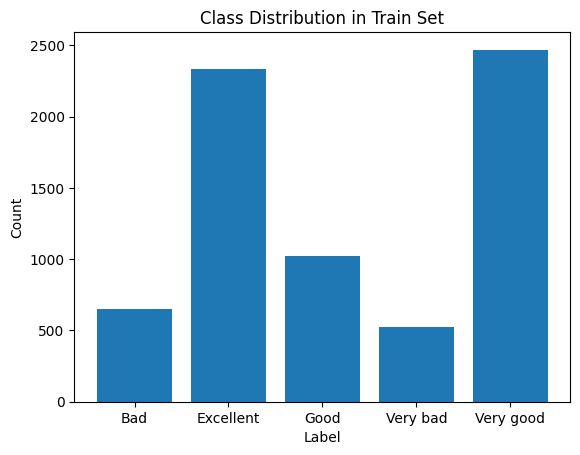

In [ ]:
train_counts = df["review"].value_counts().sort_index()

plt.figure()
plt.bar(train_counts.index, train_counts.values)
plt.title("Class Distribution in Train Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

***This indicates data bias that we need to handle.***

Generating Word Clouds...


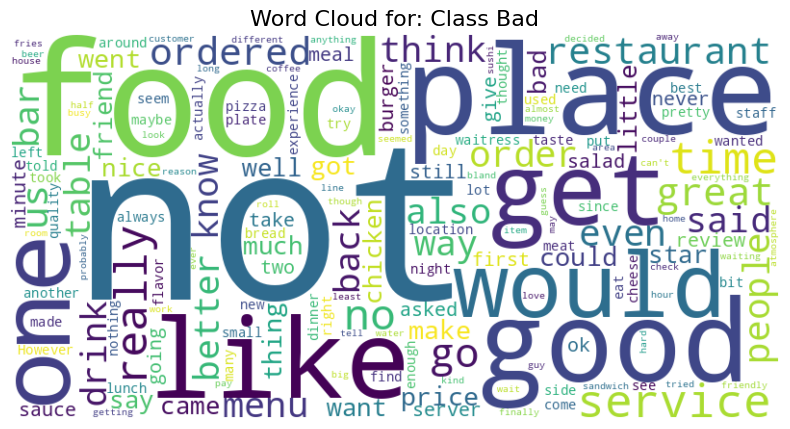

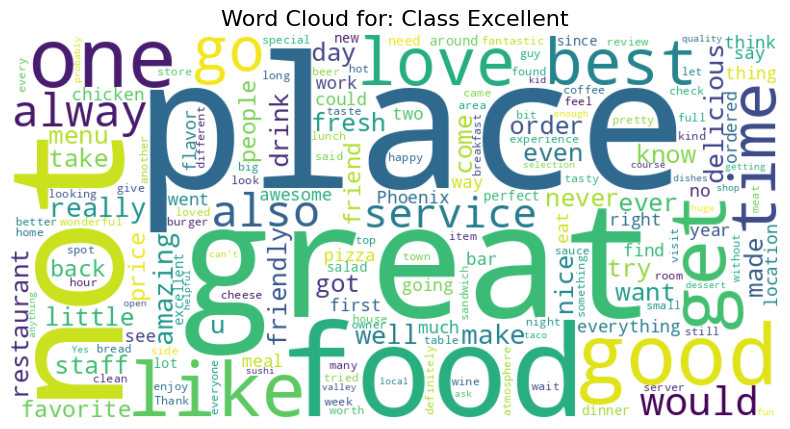

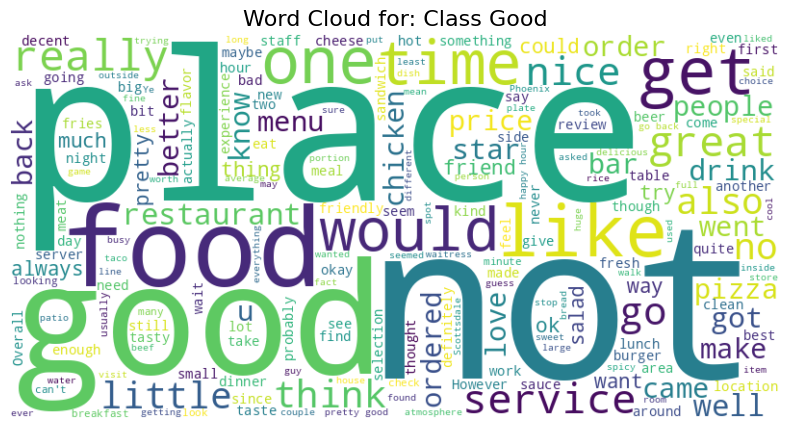

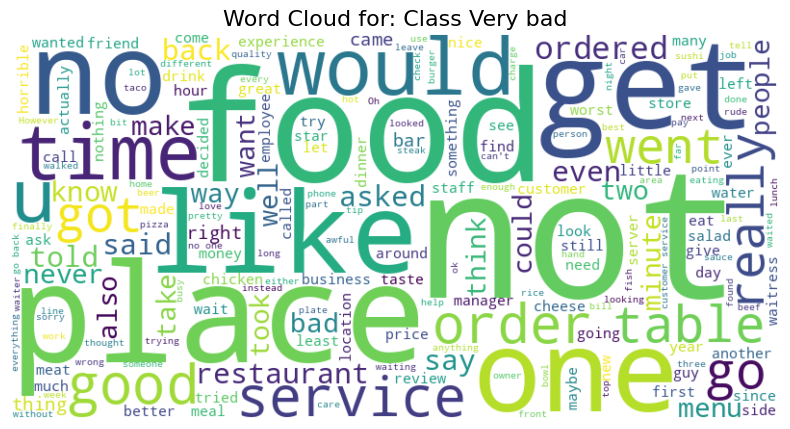

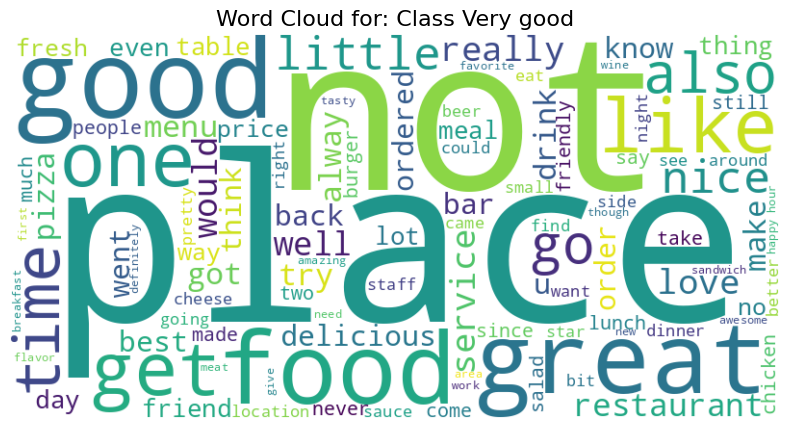

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords

# 1. Setup Labels & Stop Words
id_to_label = {
    0: 'Bad',
    1: 'Excellent',
    2: 'Good',
    3: 'Very bad',
    4: 'Very good'
}

stop_words = set(stopwords.words('english'))
# Keep negation words because they are critical for sentiment
for word in ['not', 'no', 'nor', 'none', 'never']:
    stop_words.discard(word)

# 2. Iterate and Plot Separately
# We use 'train_df' and 'label' based on your previous preprocessing steps
unique_labels = sorted(df['review'].unique())

print("Generating Word Clouds...")

for label_id in unique_labels:
    # Filter text for this specific class
    # converting to string ensures no errors with potential NaNs or non-string types
    class_text = " ".join(df[df['review'] == label_id]['text'].astype(str))

    # Generate Cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stop_words,
        min_font_size=10
    ).generate(class_text)

    # Create a NEW figure for each class
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")

    # Title
    class_name = id_to_label.get(label_id, f"Class {label_id}")
    plt.title(f"Word Cloud for: {class_name}", fontsize=16)

    # Display immediately
    plt.show()

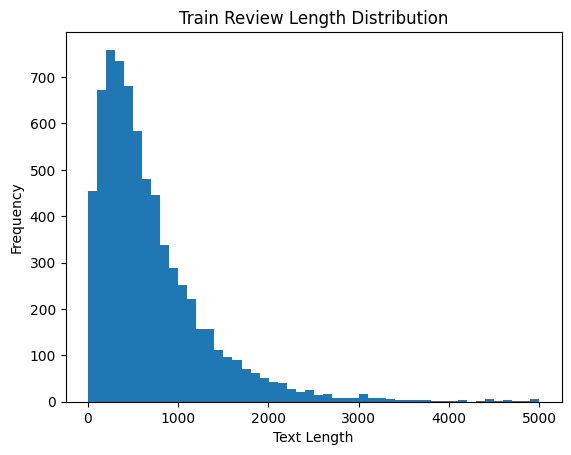

In [ ]:
train = df.copy()
train["text_length"] = df["text"].apply(len)
plt.figure()
plt.hist(train["text_length"], bins=50)
plt.title("Train Review Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

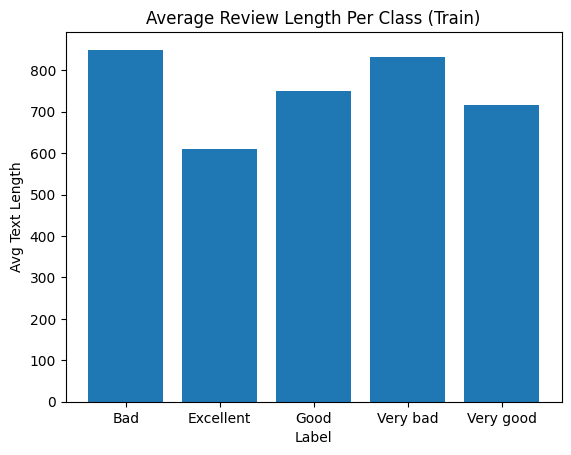

In [ ]:
avg_len = train.groupby("review")["text_length"].mean()

plt.figure()
plt.bar(avg_len.index, avg_len.values)
plt.title("Average Review Length Per Class (Train)")
plt.xlabel("Label")
plt.ylabel("Avg Text Length")
plt.show()


# **Data Preparation**

## *Train Data splitting*
*To evaluate the behaviour of the models before submission*

In [ ]:
train_df, temp_df = train_test_split(df,test_size=0.2, stratify=df['review'], random_state=42, shuffle=True)
# split the rest 20% into Validation (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['review'], random_state=42, shuffle=True)
print(f"train size: {len(train_df)}")
print(f"val size:   {len(val_df)}")
print(f"test size:  {len(test_df)}")

train size: 5600
val size:   700
test size:  700


In [ ]:
print("train class distribution:")
display(train_df['review'].value_counts(normalize=True)*100)
print("\n------------------------------------------\n")
print("validation class distribution:")
display(val_df['review'].value_counts(normalize=True)*100)
print("\n------------------------------------------\n")
print("test class distribution:")
display(test_df['review'].value_counts(normalize=True)*100)

train class distribution:


,proportion
review,
Very good,35.267857
Excellent,33.357143
Good,14.625000
Bad,9.267857
Very bad,7.482143



------------------------------------------

validation class distribution:


,proportion
review,
Very good,35.285714
Excellent,33.428571
Good,14.571429
Bad,9.142857
Very bad,7.571429



------------------------------------------

test class distribution:


,proportion
review,
Very good,35.285714
Excellent,33.285714
Good,14.714286
Bad,9.285714
Very bad,7.428571


## *Train Data Pre-processing*

### *Tools and Functions*

In [ ]:
label_encoder = LabelEncoder()
sid = SentimentIntensityAnalyzer()
tknzr = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
tokenizer = BertTokenizer.from_pretrained('nlptown/bert-base-multilingual-uncased-sentiment')

In [ ]:
# Light cleaning
def pre_clean(text):
    """
    Cleans text for Transformer models (BERT, RoBERTa).
    Preserves: Punctuation, Case, Stopwords, Numbers.
    Converts: Emojis to text.
    Removes: HTML, URLs, Handles.
    """
    text = BeautifulSoup(text, 'html.parser').get_text()

    # 2. REMOVE MASHED METADATA
    # Pattern: Matches a digit+dot+digit sequence at the end of text
    # This strips the "20.99910.51" garbage from the end
    text = re.sub(r'[0-9]+\.[0-9]+[0-9\.]*$', '', text)

    # 3. REMOVE CLOSED BANNERS
    text = re.sub(r'(?:=\s*){2,}\s*closed\s*(?:=\s*){2,}', ' ', text)
    text = re.sub(r'(?:=\s*){2,}', ' ', text)

    # 4. FIX SPACED APOSTROPHES (example for "don ' t")
    # This glues "don ' t" back to "don't" so we can expand it later
    text = re.sub(r"\s+'\s+", "'", text)

    # 5. FIX BROKEN EMOTICONS
    text = re.sub(r'([:;=])\s*([-o^]?)\s*([)(DPp/|])', r'\1\2\3', text)

    # 6. MAP EMOTICONS TO WORDS
    emo_map = {
        r':\(': ' sad ', r':-\(': ' sad ',
        r':\)': ' happy ', r':-\)': ' happy ',
        r':d': ' happy ', r':p': ' playful '
    }
    for pattern, word in emo_map.items():
        text = re.sub(pattern, word, text)

    # 7. EXPAND CONTRACTIONS (don't -> do not)
    text = contractions.fix(text)

    # 8. DEMOJIZE (😊 -> smile)
    text = emoji.demojize(text, delimiters=(" ", " "))

    # 9. PURE TEXT ONLY
    # Replaces everything that isn't a letter or space with a space.
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 10. Normalize Whitespace
    text = " ".join(text.split())

    return text

def truncate_smart_sentences(text, max_words=512):
    sentences = nltk.sent_tokenize(str(text))

    # Quick check on total length
    total_words = sum(len(s.split()) for s in sentences)
    if total_words <= max_words:
        return text

    # Keep adding sentences from start and end until budget is full
    head_sents = []
    tail_sents = []
    current_words = 0

    # Using pointers to pick from start and end
    i = 0
    j = len(sentences) - 1

    while i < j and current_words < max_words:
        # Always prioritize the end (Verdict) if we have to choose
        if current_words + len(sentences[j].split()) < max_words:
            tail_sents.append(sentences[j])
            current_words += len(sentences[j].split())
            j -= 1

        # Then add from the start (Setup)
        if i < j and current_words + len(sentences[i].split()) < max_words:
            head_sents.append(sentences[i])
            current_words += len(sentences[i].split())
            i += 1
        else:
            break

    # Reassemble in correct order
    # tail_sents was collected backwards, so reverse it
    final_text = " ".join(head_sents + tail_sents[::-1])
    return final_text

In [ ]:
# Sentiment Analysis using Vader
def get_vader_features(text):
    scores = sid.polarity_scores(text)
    # Return all 4 components: negative, neutral, positive, and compound
    return pd.Series([scores['neg'], scores['neu'], scores['pos'], scores['compound']])


# Sentiment analysis using BERT

sentiment_pipeline = pipeline("sentiment-analysis",
                              model="nlptown/bert-base-multilingual-uncased-sentiment",
                              device=0)

def get_sentiment_score(text):
    try:
        # Enable truncation
        text = truncate_smart_sentences(text)
        result = sentiment_pipeline(text, truncation=True, max_length=512)[0]
        label = result['label']

        # This model outputs labels like "1 star", "5 stars"
        if 'star' in label:
            stars = int(label.split(' ')[0])

            # DIRECT MAPPING
            mapping = {
                1: -1.0,  # Very Bad
                2: -0.5,  # Bad
                3: 0.0,   # Neutral
                4: 0.5,   # Good
                5: 1.0    # Excellent
            }
            return mapping.get(stars, 0.0)

        # Fallback if the model behaves unexpectedly
        return 0.0

    except Exception as e:
        print(f"Error on row: {e}")
        return 0.0

### *Pre-processing*

In [ ]:
train_df = train_df.drop(columns=["id"])
train_df.columns

Index(['text', 'review'], dtype='object')

In [ ]:
# Feature encoding

train_df["label"] = label_encoder.fit_transform(train_df["review"])
train_df = train_df.drop(columns=["review"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_mapping

{'Bad': np.int64(0),
 'Excellent': np.int64(1),
 'Good': np.int64(2),
 'Very bad': np.int64(3),
 'Very good': np.int64(4)}

In [ ]:
# Initial cleaning

train_df['clean_text'] = train_df['text'].apply(pre_clean)
train_df = train_df.drop(columns=["text"])

In [ ]:
train_df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = train_df['clean_text'].apply(get_vader_features)


In [ ]:
# 3 (Very Bad)
# 0 (Bad)
# 2 (Good)
# 4 (Very Good)
# 1 (Excellent)
pd.set_option('display.max_colwidth', None)
display(train_df.head(20))

,label,clean_text,vader_neg,vader_neu,vader_pos,vader_compound
4424,3,t was family day the ex and like to see our son smile and we were starving after driving around for a while we pulled up to rriba s and said what the hell hat is also what we said when some of the food came as in what the hell is this o positive first he server was pretty quick and he gave refills without being asked hips and salsa were good hips were warm and salsa had a nice suprising kick ick do sound like an old lady organ and ordered fish tacos and beef tacos respectively so we could swap one for one ish was ok nothing spectacular but honestly would rather pay for one at freakin el aco or ubios ot worth it here ice was ok some flavor probably converted rice though eans were blended do not know about you but like to see some actual in my beans his stuff was like brown goo he beef taco was just weird swear to od is tasted like gyro meat could not eat much of it ast but not least om ordered the hite ands himichanga hat sh t looked nasty to be honest overed with some gooey white sauce filled with pork he said it tasted like hot dog m yikes e took about bites and was full he did not like it also had a margarita it was and did not taste very good would rather have one that size that tasted nice h well ne star for the chips and salsa ike said the fish taco was okay but every thing was just way over priced inal verdict e decided to go there again,0.065,0.751,0.184,0.9861
434,4,y husband and lucked into one of the best dining experiences in a long time on a recent business trip to he hummous appetizer was exceptional as was the what is in this steak dish tender filet wrapped in yukon gold potatoes how comforting is ice selection of wine by the glass he only disappointment was a dessert referred to as a twist on iramisu but which bore no resemblance to it at all with toffee cookie dough ice cream will go back next time in town but try a different dessert,0.079,0.852,0.068,-0.2617
2299,4,ove this place reat selection of beers cheap per beer happy hour relaxed atmosphere and walking distance to the ight ail ome nights they have live music which is not always to my taste but like that they provide a venue for local artists and musicians on top of everything else n irst ridays it is packed so good or bad depending on your feeling about crowds avoid it those nights but on other nights it is just a very cool and comfortable place to hang out ometimes parking is kind of hard to find,0.086,0.698,0.216,0.9326
5868,4,h ogurtland why cannot resist your calling had to run an errand and saw this location next to a edex ffice perfect dropped in and ordered ouble ookies ream trawberry and heesecake topped with eanuts aptain runch and eese s eanut utter up for around http www yelp com biz photos o c y v w j c g select couxvx l xn g http www yelp com biz photos o c y v w j c g select xzd ms v a vn irgs t was of course awesome he line was very short too even though the weather was in the mid s boy did luck out eturn actor,0.000,0.885,0.115,0.8957
3132,3,ot fudge unday was watered down so much ou would do much better by going to mcdonalds his is not the first time should quit giving this place chances am disappointed every time once asked for hot fudge on the bottom of my sundae and was charged more he staff is rarely friendly hey should consider being friendly since it airy ueen a place that takes many of us back to our childhoods he array of desserts are so wonderful why not serve them wonderfully and with a smile and not like you hate your job and just want to go home,0.127,0.719,0.154,0.4985
1105,2,o was meeting some friends here last night for drinks for a friend s birthday e were supposed to meet at but it was around when we actually got to the bar e walked in and had our s checked and then stood around awkwardly am not sure why this happened but after a few minutes we were asked if we needed a table up that is why we are here o we were seated near the bar he place is large a

In [ ]:
from transformers import pipeline
from tqdm import tqdm

In [ ]:

# Sentiment analysis using BERT
tqdm.pandas()
sentiment_pipeline = pipeline("sentiment-analysis",
                              model="nlptown/bert-base-multilingual-uncased-sentiment",
                              device=0)

# Apply Skip truncation, then calculate BERT score
train_df['bert_score'] = train_df['clean_text'].progress_apply(get_sentiment_score)

'\n# Sentiment analysis using BERT\ntqdm.pandas()\nsentiment_pipeline = pipeline("sentiment-analysis",\n                              model="nlptown/bert-base-multilingual-uncased-sentiment",\n                              device=0)\n\n# Apply Skip truncation, then calculate BERT score\ntrain_df[\'bert_score\'] = train_df[\'clean_text\'].progress_apply(get_sentiment_score)\n'

In [ ]:

# Augmentation to handle bias

# --- 1. SETUP CONTEXTUAL AUGMENTER ---
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Loading BERT Augmenter on: {device_type}...")

# ContextualWordEmbsAug uses BERT to find context-aware substitutes
# action="substitute" replaces words; "insert" adds new words
aug_bert = naw.ContextualWordEmbsAug(
    model_path='bert-base-uncased',
    action="substitute",
    device=device_type,
    batch_size=32,
    aug_p=0.4
)



# --- 2. ROBUST AUGMENTATION LOOP ---
class_counts = train_df["label"].value_counts()
max_count = class_counts.max()
augmented_rows = []

print("Starting robust augmentation with consistency check...")

for label, count in class_counts.items():
    if count < max_count:
        needed = max_count - count
        print(f"\nAugmenting Class {label}: Need {needed} rows")

        subset = train_df[train_df["label"] == label]

        # Sample 2x needed because we will filter out "bad" augmentations
        sample_size = int(needed * 3.0)
        samples = subset.sample(n=sample_size, replace=True, random_state=42)

        text_list = samples["clean_text"].tolist()
        label_list = samples["label"].tolist()

        batch_size = 32
        class_augmented_rows = []

        for i in tqdm(range(0, len(text_list), batch_size), desc=f"Class {label}"):
            if len(class_augmented_rows) >= needed:
                break

            batch_texts = text_list[i : i+batch_size]
            batch_labels = label_list[i : i+batch_size]

            try:
                # Generate augmentations
                new_texts = aug_bert.augment(batch_texts)

                for orig, new_text, lbl in zip(batch_texts, new_texts, batch_labels):

                    if len(class_augmented_rows) >= needed:
                        break
                    # 1. Empty/Identity Check
                    if not new_text or str(new_text).strip() == "" or new_text == orig:
                        continue

                    # 2. SENTIMENT CONSISTENCY CHECK
                    # Calculate scores for BOTH original and new
                    orig_bert_score = get_sentiment_score(orig)
                    new_bert_score = get_sentiment_score(new_text)

                    # If the sentiment flipped significantly (e.g. > 0.5 difference), discard it!
                    # This prevents "Good food" becoming "Bad food"
                    if abs(orig_bert_score - new_bert_score) > 0.5:
                        continue

                    # If it passes, calculate final features and keep it
                    vader_comp = sid.polarity_scores(new_text)['compound']

                    class_augmented_rows.append({
                        "clean_text": new_text,
                        "label": lbl,
                        "vader_compound": vader_comp,
                        "bert_score": new_bert_score
                    })

            except Exception as e:
                print(f"Batch failed: {e}")
                continue

        # Add to main list
        augmented_rows.extend(class_augmented_rows[:needed])

# --- 3. MERGE & SAVE ---
keep_cols = ['clean_text', 'label', 'vader_compound', 'bert_score']

if augmented_rows:
    augmented_df = pd.DataFrame(augmented_rows)
    # Deduplicate again just to be safe
    augmented_df = augmented_df.drop_duplicates(subset=['clean_text'])

    train_df_balanced = pd.concat([train_df[keep_cols], augmented_df[keep_cols]])
else:
    train_df_balanced = train_df[keep_cols].copy()

# Final shuffle
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal Class Distribution:")
print(train_df_balanced["label"].value_counts())

'\n# Augmentation to handle bias\n\n# --- 1. SETUP CONTEXTUAL AUGMENTER ---\ndevice_type = \'cuda\' if torch.cuda.is_available() else \'cpu\'\nprint(f"Loading BERT Augmenter on: {device_type}...")\n\n# ContextualWordEmbsAug uses BERT to find context-aware substitutes\n# action="substitute" replaces words; "insert" adds new words\naug_bert = naw.ContextualWordEmbsAug(\n    model_path=\'bert-base-uncased\',\n    action="substitute",\n    device=device_type,\n    batch_size=32,\n    aug_p=0.4\n)\n\n\n\n# --- 2. ROBUST AUGMENTATION LOOP ---\nclass_counts = train_df["label"].value_counts()\nmax_count = class_counts.max()\naugmented_rows = []\n\nprint("Starting robust augmentation with consistency check...")\n\nfor label, count in class_counts.items():\n    if count < max_count:\n        needed = max_count - count\n        print(f"\nAugmenting Class {label}: Need {needed} rows")\n\n        subset = train_df[train_df["label"] == label]\n\n        # Sample 2x needed because we will filter out 

In [ ]:
# train_df_balanced.to_csv("train_balanced_aug.csv", index=False)

## *Train data after augmentation*




In [ ]:
train_df_balanced = pd.read_csv("/content/drive/MyDrive/NeuralNetworksProjectDataset/train_balanced_aug (1).csv")

In [ ]:
temp = train_df_balanced.copy()
print(f"Number of duplicated rows: {temp.duplicated().sum()}")
display(temp[temp.duplicated()])

Number of duplicated rows: 2


,clean_text,label,vader_compound,bert_score
6486,this review is for the chain in general the location we went to is new so it is not in yelp yet once it is i will put this review there as well we were there on friday at pm the reason i gave it stars is because the burger was very good and it was made the way i asked for it my husbands burger was not but the server and the fries left a lot to be desired let me preface by saying that we had been to several other locations i like my fries crispy i ask for them well done extra crispy scorched tortured hollow tubes whatever their buzz word is for well done the location will comply every other guys has complied but not the one at tatum and shea she said that corporate said they are not to cook the fries that way so if we were to put up with soggy fries yes soggy then we did not want them she also interrupted us several times which is rude then she went and called corporate just to double check for us and she came to the table and said they said no they were not to cook them that way seriously we did not ask for her to do this she actually accused us of being undercover shoppers we started to say something and then again she interupted listen if you explain that our choice is not how the company wishes to present their product and we still choose to have them a different way you should comply it is after all our money and our decision i was raised with the rules that the customer is always right and if the customer is wrong refer to rule number we will not return they have lost our business and i hope she loses her job if you want to try a really good burger and fries place go to paradise valley burger company at th street and bell you will not be disappointed,0,0.7876,0.5
8801,excellent,1,0.5719,1.0


In [ ]:
temp = temp.drop_duplicates()
print(f"Number of duplicated rows: {temp.duplicated().sum()}")

Number of duplicated rows: 0


In [ ]:
# 3 (Very Bad)
# 0 (Bad)
# 2 (Good)
# 4 (Very Good)
# 1 (Excellent)

In [ ]:
display(temp.head(20))

,clean_text,label,vader_compound,bert_score
0,came here for lunch recently with active yelper and friend brett b i am sure he will post up his own review of the place this is the kind of place you walk up to the register and place your order then take a plastic number to your table and the server brings you your food you also get your glass and go fill er up at the fountain yourself i was not sure what to expect but felt good vibes the minute i asked how big is the salad and the guy at the register walked into the kitchen to bring me a dish to show me that was nice and above my expectation as most places the servers will make a size with their hands and shrug and say i do not know about like this so yeah i like that this guy actually showed me a plate and made a mound with his hand to show me some kind of size of the salad when i ordered just water he went to give me a plastic cup with a lid and then said you know what just take a regular glass it is more comfortable he trusted me not to fill up my glass with anything but water and i did only drink water that was nice and made me feel like an adult not like at some places much cheaper than this place that give you a plastic cup like the ones you pee in at the doctor s office when you order water i really enjoyed my lunch here had a chicken caesar salad one of my favorite things to order pretty much anywhere i go because i will never make it at home along with a cheese pizza the caesar salad for those who have a love affair with this meal was perfect the portion was generous and it was chopped and tossed the chicken was shredded and mixed in with the salad which makes such a difference in getting an even distribution and reducing pain in the ass ness of having to cut up a chicken breast atop a salad with oversized utensils like at so many other places it was perfectly dressed too not too heavy just right and the parmesan cheese was shaved over it rather than shredded or grated nice touch excellent flavor every mouthful the cheese pizza was a cripsy ultra thin crust delicious red sauce kind of sweet in a good way and the cheeses were mozzarella and fontina the saltiness mixed really well with the sweetness of the sauce and made this simple pizza taste extraordinary granted having had some beyond extraordinary pizza in new york i am spoiled and have to say it was not as good as my favorite thin crust pizza from totonno s in nyc s upper east side but still darn good i would eat it again i took some home and it did not look like it heated up well later on when my husband was having it brett had the tomato gorgonzola chicken salad on mixed greens i think it had pine nuts too i got to taste it and it was even more flavorful than mine either one of these would be an excellent choice for those of you who like to order salads delicious and the service was great the manager even came by our tables to refill our glasses for us though the drinks were self serve from a fountain the place was not busy when we got there but it picked up as we were finishing our meals great food great service great vibe i hope this place sticks around definitely would eat there again looking forward to it even,2,0.9991,0.5
1,is this great sushi no does this food reinvent the sushi wheel not even close will i have a foodgasm not a chance when i am craving an amazing sushi meal i will go to yasu why i really really like teharu the food is fresh while it is not amazing fish there is nothing wrong with it nothing here to get sick from all the standards are readily available and if you want something not already on the belt they will gladly make it for you the conveyor really feeds into my lack of patience i sat down ordered an iced green tea and started pulling plates off the belt yes i was eating sushi within seconds of sitting down the price is a huge plus i met a friend for lunch we each had iced tea several plates with or roll slices seaweed salad sunumono salad and a couple nigiri and i was out of there for l

In [ ]:
# Setup FastText Model (Downloads ~1GB if not cached)

fasttext_model_path = '/content/drive/MyDrive/fasttext-wiki-news-subwords-300.model'

if os.path.exists(fasttext_model_path):
    print(f"Loading FastText model from {fasttext_model_path}...")
    ft_model = gensim.models.KeyedVectors.load(fasttext_model_path)
else:
    print("Downloading FastText model... (This may take 1-2 minutes)")
    ft_model = api.load('fasttext-wiki-news-subwords-300')
    #print(f"Saving FastText model to {fasttext_model_path}...")
    #ft_model.save(fasttext_model_path)
    print("Model saved.")

Loading FastText model from /content/drive/MyDrive/fasttext-wiki-news-subwords-300.model...


In [ ]:
# fasttext_model_path = '/content/drive/MyDrive/fasttext-wiki-news-subwords-300.model'
# ft_model.save(fasttext_model_path)

In [ ]:
# Aggressive cleaning for non-transformers

# Initialize Stop Words
stop_words = set(stopwords.words('english'))
# CRITICAL: Keep negation words
for word in ['not', 'no', 'nor', 'none', 'never']:
    stop_words.discard(word)

def aggressive_clean_for_fasttext(text):
    """
    Prepares text specifically for FastText averaging:
    1. Removes metadata tags like [UK] completely.
    2. Lowercases (handled by preserve_case=False).
    3. Removes Stop Words.
    4. Removes Punctuation/Symbols/Emojis (including :sluurrpp:).
    """
    text = str(text).lower()
    # Expand contractions (e.g., "don't" -> "do not")
    text = contractions.fix(text)
    # Convert emojis to text
    text = emoji.demojize(text, delimiters=(" ", " "))
    # Remove ONLY URLs and Handles, keep punctuation
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+', '', text)
    # Add spacing around punctuation to treat them as tokens
    text = re.sub(r"([?.!,])", r" \1 ", text)
    text = re.sub(r'["\n\r\t]', ' ', text)
    return " ".join(text.split())


print("Creating aggressive text column for FastText...")
# We use a NEW column 'networks_text' so we don't overwrite the text needed for BERT

temp['networks_text'] = temp['clean_text'].apply(aggressive_clean_for_fasttext)

print("Sample of Aggressive Cleaned Text:")
print(temp[['clean_text', 'networks_text']].head())


print("\n--- Starting FastText Vectorization ---")

def get_fasttext_vector(text, model):
    # Since text is already cleaned, we just split by space
    words = text.split()

    word_vectors = []
    for word in words:
        try:
            # FastText handles subwords/typos automatically
            vector = model[word]
            word_vectors.append(vector)
        except KeyError:
            pass

    # Handle empty reviews (e.g., review was just "...")
    if len(word_vectors) == 0:
        return np.zeros(300)

    return np.mean(word_vectors, axis=0)

# Apply Vectorization
X_embeddings = np.stack(
    temp['networks_text'].apply(lambda x: get_fasttext_vector(x, ft_model))
)

Creating aggressive text column for FastText...
Sample of Aggressive Cleaned Text:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [ ]:
temp.duplicated().sum()

np.int64(0)

In [ ]:
display(temp[['clean_text', 'networks_text']].head(20))

,clean_text,networks_text
0,came here for lunch recently with active yelper and friend brett b i am sure he will post up his own review of the place this is the kind of place you walk up to the register and place your order then take a plastic number to your table and the server brings you your food you also get your glass and go fill er up at the fountain yourself i was not sure what to expect but felt good vibes the minute i asked how big is the salad and the guy at the register walked into the kitchen to bring me a dish to show me that was nice and above my expectation as most places the servers will make a size with their hands and shrug and say i do not know about like this so yeah i like that this guy actually showed me a plate and made a mound with his hand to show me some kind of size of the salad when i ordered just water he went to give me a plastic cup with a lid and then said you know what just take a regular glass it is more comfortable he trusted me not to fill up my glass with anything but water and i did only drink water that was nice and made me feel like an adult not like at some places much cheaper than this place that give you a plastic cup like the ones you pee in at the doctor s office when you order water i really enjoyed my lunch here had a chicken caesar salad one of my favorite things to order pretty much anywhere i go because i will never make it at home along with a cheese pizza the caesar salad for those who have a love affair with this meal was perfect the portion was generous and it was chopped and tossed the chicken was shredded and mixed in with the salad which makes such a difference in getting an even distribution and reducing pain in the ass ness of having to cut up a chicken breast atop a salad with oversized utensils like at so many other places it was perfectly dressed too not too heavy just right and the parmesan cheese was shaved over it rather than shredded or grated nice touch excellent flavor every mouthful the cheese pizza was a cripsy ultra thin crust delicious red sauce kind of sweet in a good way and the cheeses were mozzarella and fontina the saltiness mixed really well with the sweetness of the sauce and made this simple pizza taste extraordinary granted having had some beyond extraordinary pizza in new york i am spoiled and have to say it was not as good as my favorite thin crust pizza from totonno s in nyc s upper east side but still darn good i would eat it again i took some home and it did not look like it heated up well later on when my husband was having it brett had the tomato gorgonzola chicken salad on mixed greens i think it had pine nuts too i got to taste it and it was even more flavorful than mine either one of these would be an excellent choice for those of you who like to order salads delicious and the service was great the manager even came by our tables to refill our glasses for us though the drinks were self serve from a fountain the place was not busy when we got there but it picked up as we were finishing our meals great food great service great vibe i hope this place sticks around definitely would eat there again looking forward to it even,came here for lunch recently with active yelper and friend brett b i am sure he will post up his own review of the place this is the kind of place you walk up to the register and place your order then take a plastic number to your table and the server brings you your food you also get your glass and go fill er up at the fountain yourself i was not sure what to expect but felt good vibes the minute i asked how big is the salad and the guy at the register walked into the kitchen to bring me a dish to show me that was nice and above my expectation as most places the servers will make a size with their hands and shrug and say i do not know about like this so yeah i like that this guy actually showed me a plate and made a mound with his hand to show me some kind of size of the salad when i ordered just water he went to give me

#**Data formatting for Models training**

## Networks

In [ ]:
# For non-tranformers
def preprocess_test_data(df, ft_model, sentiment_pipeline, sid, tknzr, stop_words, label_mapping=None):
    """
    Full preprocessing pipeline for test/inference data.

    Args:
        df (pd.DataFrame): The raw test dataframe (must contain 'text').
        ft_model: Loaded Gensim FastText model.
        sentiment_pipeline: Loaded Hugging Face sentiment pipeline.
        sid: NLTK SentimentIntensityAnalyzer instance.
        tknzr: NLTK TweetTokenizer instance.
        stop_words: Set of stopwords.
        label_mapping (dict, optional): Dictionary to map 'review' strings to integers (e.g. {'Good': 2}).

    Returns:
        X_final (np.array): The processed feature matrix (FastText + VADER + BERT).
        y_final (np.array or None): The label array if 'review' column exists, else None.
    """

    # 1. Create a copy to avoid SettingWithCopy warnings
    df = df.copy()

    # 2. Remove 'id' column if it exists
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    # 3. Encode Target Variable (if 'review' column exists)
    y_final = None
    if 'review' in df.columns and label_mapping:
        print("Encoding 'review' column...")
        # Map string labels to integers (e.g. 'Excellent' -> 1)
        # Using map is safer than LabelEncoder for test data to handle unseen labels gracefully (though unlikely here)
        df['label'] = df['review'].map(label_mapping)
        y_final = df['label'].values
        # Drop review as we now have label
        df = df.drop(columns=['review'])

    # --- FEATURE ENGINEERING ---

    print("Generating VADER scores...")
    # 4. VADER Sentiment (on Raw Text)
    # We only need the 'compound' score for the final matrix based on your training code
    df['vader_compound'] = df['text'].apply(lambda x: sid.polarity_scores(str(x))['compound'])

    print("Cleaning text (Light Clean for BERT)...")

    df['clean_text'] = df['text'].apply(pre_clean)
    df['clean_text']= df['clean_text'].apply(truncate_smart_sentences)
    print("Generating BERT scores (this may take time)...")
    # 6. BERT Score Function (Helper)
    def get_bert_score(text):
        try:
            # Truncate to 512 tokens to prevent errors
            result = sentiment_pipeline(text, truncation=True, max_length=512)[0]
            label = result['label']
            if 'star' in label:
                stars = int(label.split(' ')[0])
                # Direct mapping from your notebook
                mapping = {1: -1.0, 2: -0.5, 3: 0.0, 4: 0.5, 5: 1.0}
                return mapping.get(stars, 0.0)
            return 0.0
        except Exception as e:
            return 0.0

    # Apply BERT scoring
    df['bert_score'] = df['clean_text'].apply(get_bert_score)

    print("Cleaning text (Aggressive Clean for FastText)...")
    # 7. Aggressive Cleaning Function (Helper)
    def aggressive_clean(text):
        # Remove bracketed text (safety check)
        text = re.sub(r'\[[^]]*\]', '', str(text))
        # Tokenize (preserves structure for now)
        tokens = tknzr.tokenize(text)
        clean_tokens = []
        for word in tokens:
            # Remove stop words and non-alphanumeric (removes punctuation/emojis)
            if word in stop_words or not word.isalnum():
                continue
            clean_tokens.append(word)
        return " ".join(clean_tokens)

    df['networks_text'] = df['clean_text'].apply(aggressive_clean)

    print("Generating FastText embeddings...")
    # 8. FastText Vectorizer (Helper)
    def get_fasttext_vector(text, model):
        words = text.split()
        word_vectors = []
        for word in words:
            try:
                vector = model[word]
                word_vectors.append(vector)
            except KeyError:
                pass
        if len(word_vectors) == 0:
            return np.zeros(300)
        return np.mean(word_vectors, axis=0)

    # Create the embedding matrix
    X_embeddings = np.stack(
        df['networks_text'].apply(lambda x: get_fasttext_vector(x, ft_model))
    )

    # --- FINAL STACKING ---

    print("Stacking features...")
    # Extract VADER and BERT as 2D arrays
    vader_features = df[['vader_compound']].values
    bert_features = df[['bert_score']].values

    # Combine: [FastText (300) + VADER (1) + BERT (1)] -> Total 302 columns
    X_final = np.hstack([X_embeddings, vader_features, bert_features])

    print(f"Done! Processed shape: {X_final.shape}")

    return X_final, y_final
# label_mapping = {'Bad': 0, 'Excellent': 1, 'Good': 2, 'Very bad': 3, 'Very good': 4}

In [ ]:
# For non-tranformers -> combine: [FastText (Semantic) + VADER (Intensity) + BERT (Context)]
vader_features = temp[['vader_compound']].values
bert_features = temp[['bert_score']].values

X_train = np.hstack([X_embeddings, vader_features, bert_features])
y_train = temp['label'].values

X_test, y_test = preprocess_test_data(test_df, ft_model, sentiment_pipeline, sid, tknzr, stop_words, label_mapping)
X_val, y_val = preprocess_test_data(val_df, ft_model, sentiment_pipeline, sid, tknzr, stop_words, label_mapping)

Encoding 'review' column...
Generating VADER scores...
Cleaning text (Light Clean for BERT)...
Generating BERT scores (this may take time)...
Cleaning text (Aggressive Clean for FastText)...
Generating FastText embeddings...
Stacking features...
Done! Processed shape: (700, 302)
Encoding 'review' column...
Generating VADER scores...
Cleaning text (Light Clean for BERT)...
Generating BERT scores (this may take time)...
Cleaning text (Aggressive Clean for FastText)...
Generating FastText embeddings...
Stacking features...
Done! Processed shape: (700, 302)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# --- 1. Fix Data Encoding ---
enc = OneHotEncoder(sparse_output=False)
y_train_onehot = enc.fit_transform(y_train.reshape(-1, 1))
y_val_onehot = enc.transform(y_val.reshape(-1, 1))

# Check what classes you actually have
num_classes = y_train_onehot.shape[1]
print(f"Detected {num_classes} classes in data.")
print(f"The classes are: {enc.categories_[0]}")
# If you see [0, 1, 2, 3, 4, 5], you have 0s in your data!

Detected 5 classes in data.
The classes are: [0 1 2 3 4]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from bs4 import BeautifulSoup
import gensim.downloader as api
import os

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
MAX_LEN = 128
BATCH_SIZE = 32

Using device: cuda


In [ ]:
def preprocess_glass_box_data(df, vocab, max_len, sentiment_pipeline, sid,

                              scaler=None, label_mapping=None, is_training=False):
    """
    Preprocessing for Glass Box Neural Networks (Bi-LSTM, CNN, Transformer).
    Returns (Token_IDs, Aux_Features, Labels, Scaler)
    """
    df = df.copy()

    if 'id' in df.columns:

        df = df.drop(columns=['id'])



    # ---- Text ----

    if 'clean_text' in df.columns:

        df['final_text'] = df['clean_text'].astype(str).apply(truncate_smart_sentences)

    else:

        df['processed_text'] = df['text'].apply(pre_clean)

        df['final_text'] = df['processed_text'].apply(truncate_smart_sentences)



    # ---- Labels ----

    y_final = None

    if 'review' in df.columns and label_mapping is not None:

        df['label'] = df['review'].map(label_mapping)

        if df['label'].isna().any():

            missing = df.loc[df['label'].isna(), 'review'].unique()

            raise ValueError(f"Unmapped review labels: {missing}")

        y_final = df['label'].to_numpy(dtype=np.int64)

    elif 'label' in df.columns:

        y_final = df['label'].to_numpy(dtype=np.int64)



    if y_final is not None:

        if y_final.min() < 0 or y_final.max() > 4:

            raise ValueError(f"Label out of expected range [0..4]. min={y_final.min()}, max={y_final.max()}")



    # ---- Aux features ----

    if 'vader_compound' not in df.columns:

        df['vader_compound'] = df['final_text'].apply(lambda x: sid.polarity_scores(x)['compound'])



    if 'bert_score' not in df.columns:

        df['bert_score'] = df['final_text'].apply(get_sentiment_score)



    aux_features = df[['vader_compound', 'bert_score']].to_numpy(dtype=np.float32)



    if is_training:

        scaler = StandardScaler()

        aux_features = scaler.fit_transform(aux_features)

    else:

        if scaler is None:

            raise ValueError("Must provide a fitted scaler for validation/test data!")

        aux_features = scaler.transform(aux_features)



    # ---- Token ids ----

    pad_id = vocab.get("<PAD>", 0)

    unk_id = vocab.get("<UNK>", 1)



    token_sequences = np.full((len(df), max_len), pad_id, dtype=np.int64)

    for i, text in enumerate(df['final_text']):

        tokens = str(text).lower().split()

        ids = [vocab.get(t, unk_id) for t in tokens[:max_len]]

        token_sequences[i, :len(ids)] = ids



    return token_sequences, aux_features, y_final, scaler

In [ ]:
# ==============================
# DEFINE MAX SEQUENCE LENGTH
# ==============================
max_len = 128   # MUST match training

# ==============================
# GLASS-BOX TRAINING PREPROCESS
# ==============================
X_tokens_train, X_aux_train, y_train, scaler_glassbox = preprocess_glass_box_data(
    df=train_df,
    vocab=vocab,
    max_len=max_len,
    sentiment_pipeline=sentiment_pipeline,
    sid=sid,
    scaler=None,
    label_mapping=label_mapping,
    is_training=True
)

# Save scaler
import joblib
joblib.dump(scaler_glassbox, "scaler_glassbox.pkl")
print("✅ scaler_glassbox.pkl saved")


✅ scaler_glassbox.pkl saved


In [ ]:
# --- A. Vocabulary Builder ---
def build_vocab(texts, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

print("Building vocabulary from training data...")
# Use a cleaned version of the text to build the vocab
vocab_text = temp['clean_text'].astype(str).str.lower()
vocab = build_vocab(vocab_text, min_freq=2)
vocab_size = len(vocab)
print(f"Vocabulary Size: {vocab_size}")

# --- B. Load Pre-trained Embeddings ---
def load_embedding_matrix(word_index, ft_model, embed_dim=300):
    matrix = np.zeros((len(word_index), embed_dim))
    hits = 0
    for word, i in word_index.items():
        if word in ("<PAD>", "<UNK>"):
            continue
        if word in ft_model:
            matrix[i] = ft_model[word]
            hits += 1
    print(f"FastText Embeddings Loaded: {hits} ({hits/(len(word_index)-2):.1%})")
    return torch.tensor(matrix, dtype=torch.float32)


# Ensure ft_model is loaded
if 'ft_model' not in locals():
    print("Loading FastText...")
    ft_model = api.load('fasttext-wiki-news-subwords-300')

pretrained_weights = load_embedding_matrix(vocab, ft_model, 300)

# --- C. Execute Preprocessing ---
print("\n--- Processing Training Data ---")
train_tokens, train_aux, train_y, feature_scaler = preprocess_glass_box_data(
    temp, vocab, MAX_LEN, sentiment_pipeline, sid,
    scaler=None, label_mapping=label_mapping, is_training=True
)

print("\n--- Processing Validation Data ---")
val_tokens, val_aux, val_y, _ = preprocess_glass_box_data(
    val_df, vocab, MAX_LEN, sentiment_pipeline, sid,
    scaler=feature_scaler, label_mapping=label_mapping, is_training=False
)

print("\n--- Processing Test Data ---")
test_tokens, test_aux, test_y, _ = preprocess_glass_box_data(
    test_df, vocab, MAX_LEN, sentiment_pipeline, sid,
    scaler=feature_scaler, label_mapping=label_mapping, is_training=False
)

Building vocabulary from training data...
Vocabulary Size: 15788
FastText Embeddings Loaded: 14673 (92.9%)

--- Processing Training Data ---

--- Processing Validation Data ---

--- Processing Test Data ---


In [ ]:
class HybridReviewDataset(Dataset):
    def __init__(self, token_ids, aux_features, labels):
        self.token_ids = token_ids
        self.aux_features = aux_features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.token_ids[idx], dtype=torch.long),
            torch.tensor(self.aux_features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# Create Datasets
train_dataset = HybridReviewDataset(train_tokens, train_aux, train_y)
val_dataset = HybridReviewDataset(val_tokens, val_aux, val_y)
test_dataset = HybridReviewDataset(test_tokens, test_aux, test_y)

# Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Calculate Class Weights
class_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class Weights: {class_weights}")

Class Weights: [1.00030395 1.00030395 0.99979747 0.99979747 0.99979747]


In [ ]:
# Alias processed data for clarity and consistency with model training functions
MAX_LEN = 128
max_length = MAX_LEN
X_text_train = train_tokens
X_aux_train = train_aux
X_text_val = val_tokens
X_aux_val = val_aux
X_text_test = test_tokens
X_aux_test = test_aux

# **Model Training**

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout,
    Layer, Concatenate, Conv1D, GlobalMaxPooling1D
)
from tensorflow.keras.optimizers import Adam

import torch
from torch.utils.data import TensorDataset, DataLoader, SequentialSampler

from google.colab import files

from tensorflow.keras.layers import Lambda

## Bi-LSTM

In [ ]:
# Custom Attention Layer
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, lstm_output):
        score = tf.tanh(lstm_output)                    # tanh activation
        score = tf.matmul(score, self.W)                # linear projection → attention scores
        weights = tf.nn.softmax(score, axis=1)          # softmax over time steps
        context = weights * lstm_output                 # apply weights
        context = tf.reduce_sum(context, axis=1)        # sum → final context vector
        return context

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

def create_hybrid_bilstm_attention(
    vocab_size=20000,
    max_length=200,
    embed_dim=300,
    hidden_dim=128,
    aux_dim=2,           # VADER compound + BERT score
    output_dim=5,
    dropout=0.5,
    embedding_matrix=None
):
    # Input layers
    text_input = Input(shape=(max_length,), name='text_input')      # token IDs
    aux_input  = Input(shape=(aux_dim,), name='aux_input')          # extra features

    # Embedding layer
    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix] if embedding_matrix is not None else None,
        trainable=False if embedding_matrix is not None else True,
        mask_zero=False
    )(text_input)

    x = Dropout(dropout)(embedding)                          # dropout after embedding

    # Bi-LSTM layer
    x = Bidirectional(LSTM(hidden_dim, return_sequences=True, dropout=dropout))(x)

    # Attention layer
    x = AttentionLayer()(x)                                 # produces context vector

    # Concatenate LSTM context with auxiliary features (VADER + BERT)
    x = Concatenate()([x, aux_input])

    # Fully connected layers
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout)(x)

    # Output layer
    output = Dense(output_dim, activation='softmax', name='targets')(x)

    # Final model
    model = Model(inputs=[text_input, aux_input], outputs=output)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model

## TextCNN - 1

In [ ]:
def create_hybrid_textcnn(
    vocab_size=20000,
    max_length=200,
    embed_dim=300,
    n_filters=128,
    filter_sizes=[3,4,5],
    aux_dim=2,           # VADER + BERT score
    output_dim=5,
    dropout=0.5,
    embedding_matrix=None
):
    # Input layers
    text_input = Input(shape=(max_length,), name='text_input')
    aux_input  = Input(shape=(aux_dim,), name='aux_input')

    # Embedding layer
    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix] if embedding_matrix is not None else None,
        trainable=False if embedding_matrix is not None else True,
        mask_zero=False
    )(text_input)

    x = Dropout(dropout)(embedding)                              # dropout after embedding

    # Multiple Conv1D branches
    conv_branches = []
    for fs in filter_sizes:
        conv = Conv1D(
            filters=n_filters,
            kernel_size=fs,
            activation='relu',
            padding='valid'
        )(x)
        pooled = GlobalMaxPooling1D()(conv)                       # max_pool1d over sequence length
        conv_branches.append(pooled)

    # Concatenate all filter outputs — like torch.cat(pooled, dim=1)
    x = Concatenate()(conv_branches) if len(conv_branches) > 1 else conv_branches[0]

    x = Dropout(dropout)(x)                                      # dropout after pooling

    # Combine CNN features with auxiliary features (VADER + BERT)
    x = Concatenate()([x, aux_input])

    # Final fully connected layers
    x = Dense(256, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout)(x)

    # Output layer
    output = Dense(output_dim, activation='softmax', name='targets')(x)

    # Final model
    model = Model(inputs=[text_input, aux_input], outputs=output)
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
def train_hybrid_model(model, X_text, X_aux, y_true, epochs=20, batch_size=64, validation_data=None):
    model.fit(
        [X_text, X_aux],           # input: list of [text, aux]
        y_true,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
        verbose=1,
        shuffle=True
    )

    print("Training finished!")
    return model


def evaluate_hybrid_model(model, X_text, X_aux, y_true):
    # Predict probabilities
    y_pred_proba = model.predict([X_text, X_aux], verbose=0)

    # Convert to class indices
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true_labels = np.argmax(y_true, axis=1) if y_true.ndim > 1 else y_true

    # Accuracy
    accuracy = accuracy_score(y_true_labels, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred,
                              target_names=['Very bad', 'Bad', 'Good', 'Very good', 'Excellent']))

    return accuracy, y_pred, y_true_labels

STARTING HYBRID MODELS TRAINING

==================== Training Bi-LSTM ====================
Epoch 1/30
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3959 - loss: 1.3480
Epoch 1: val_accuracy improved from -inf to 0.47571, saving model to best_Bi-LSTM.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.3965 - loss: 1.3469 - val_accuracy: 0.4757 - val_loss: 1.2378
Epoch 2/30
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4786 - loss: 1.1856
Epoch 2: val_accuracy did not improve from 0.47571
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4787 - loss: 1.1856 - val_accuracy: 0.4714 - val_loss: 1.2681
Epoch 3/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5019 - loss: 1.1626
Epoch 3: val_accuracy improved from 0.47571 to 0.48571, saving model to best_Bi-LSTM.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.5019 - loss: 1.1625 - val_accuracy: 0.4857 - val_loss: 1.2482
Epoch 4/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy

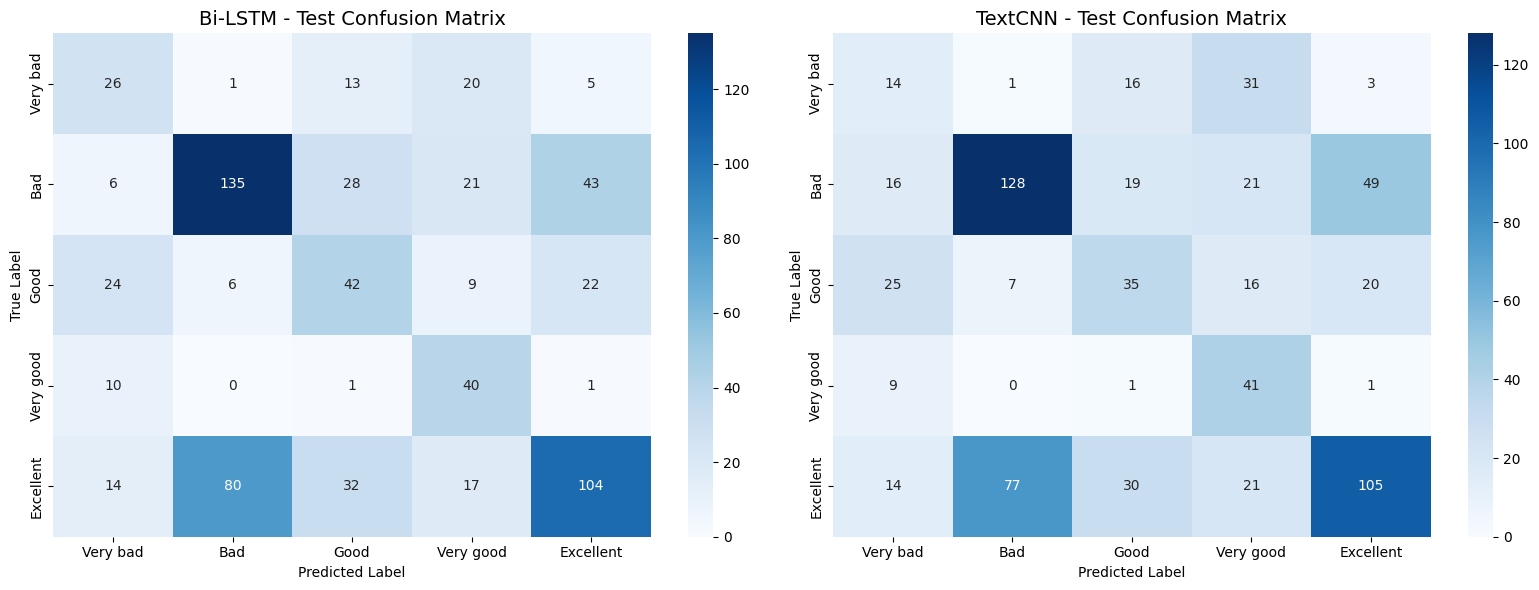


All models trained and evaluated successfully!


In [ ]:
# One-hot encode test labels
y_test_onehot = enc.transform(test_y.reshape(-1, 1))

MODELS = {
    "Bi-LSTM": create_hybrid_bilstm_attention(
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=300,
        hidden_dim=128,
        aux_dim=2,
        output_dim=5,
        dropout=0.5,
        embedding_matrix=pretrained_weights
    ),
    "TextCNN": create_hybrid_textcnn(
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=300,
        n_filters=128,
        filter_sizes=[3,4,5],
        aux_dim=2,
        output_dim=5,
        dropout=0.5,
        embedding_matrix=pretrained_weights
    )
}

results = {}

print("="*60)
print("STARTING HYBRID MODELS TRAINING")
print("="*60)

for name, model in MODELS.items():
    print(f"\n{'='*20} Training {name} {'='*20}")

    # Learning rate
    lr = 1e-3
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f'best_{name}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        [X_text_train, X_aux_train],
        y_train_onehot,
        validation_data=([X_text_val, X_aux_val], y_val_onehot),
        epochs=30,
        batch_size=64,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

    # Load best model
    model = tf.keras.models.load_model(f'best_{name}.keras',
                                      custom_objects={'AttentionLayer': AttentionLayer})

    # Final Test Evaluation
    print(f"\n--- {name} Final Test Evaluation ---")
    test_pred_proba = model.predict([X_text_test, X_aux_test], verbose=0)
    test_preds = np.argmax(test_pred_proba, axis=1)
    test_labels = np.argmax(y_test_onehot, axis=1)

    test_acc = accuracy_score(test_labels, test_preds)
    print(f"Test Accuracy: {test_acc:.4f}")
    print(classification_report(test_labels, test_preds,
                                target_names=['Very bad', 'Bad', 'Good', 'Very good', 'Excellent']))

    # Save confusion matrix
    cm = confusion_matrix(test_labels, test_preds)
    results[name] = cm

    print(f"{name} completed!\n")

# Visualization - Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes = axes.ravel()

for idx, (name, cm) in enumerate(results.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Very bad','Bad','Good','Very good','Excellent'],
                yticklabels=['Very bad','Bad','Good','Very good','Excellent'])
    axes[idx].set_title(f'{name} - Test Confusion Matrix', fontsize=14)
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\nAll models trained and evaluated successfully!")

STARTING HYBRID MODELS TRAINING (Bi-LSTM + TextCNN)

========================= Training: Bi-LSTM + Attention =========================
Epoch 1/30
154/155 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4010 - loss: 1.3459
Epoch 1: val_accuracy improved from -inf to 0.47857, saving model to best_Bi-LSTM_+_Attention.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.4015 - loss: 1.3448 - val_accuracy: 0.4786 - val_loss: 1.2143
Epoch 2/30
153/155 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4827 - loss: 1.1870
Epoch 2: val_accuracy improved from 0.47857 to 0.48857, saving model to best_Bi-LSTM_+_Attention.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.4829 - loss: 1.1868 - val_accuracy: 0.4886 - val_loss: 1.1864
Epoch 3/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4978 - loss: 1.1630
Epoch 3: val_accuracy did not improve from 0.48857
155/155 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.4978 - loss: 1.1630 - val_accuracy: 0.4843 - val_loss: 1.2

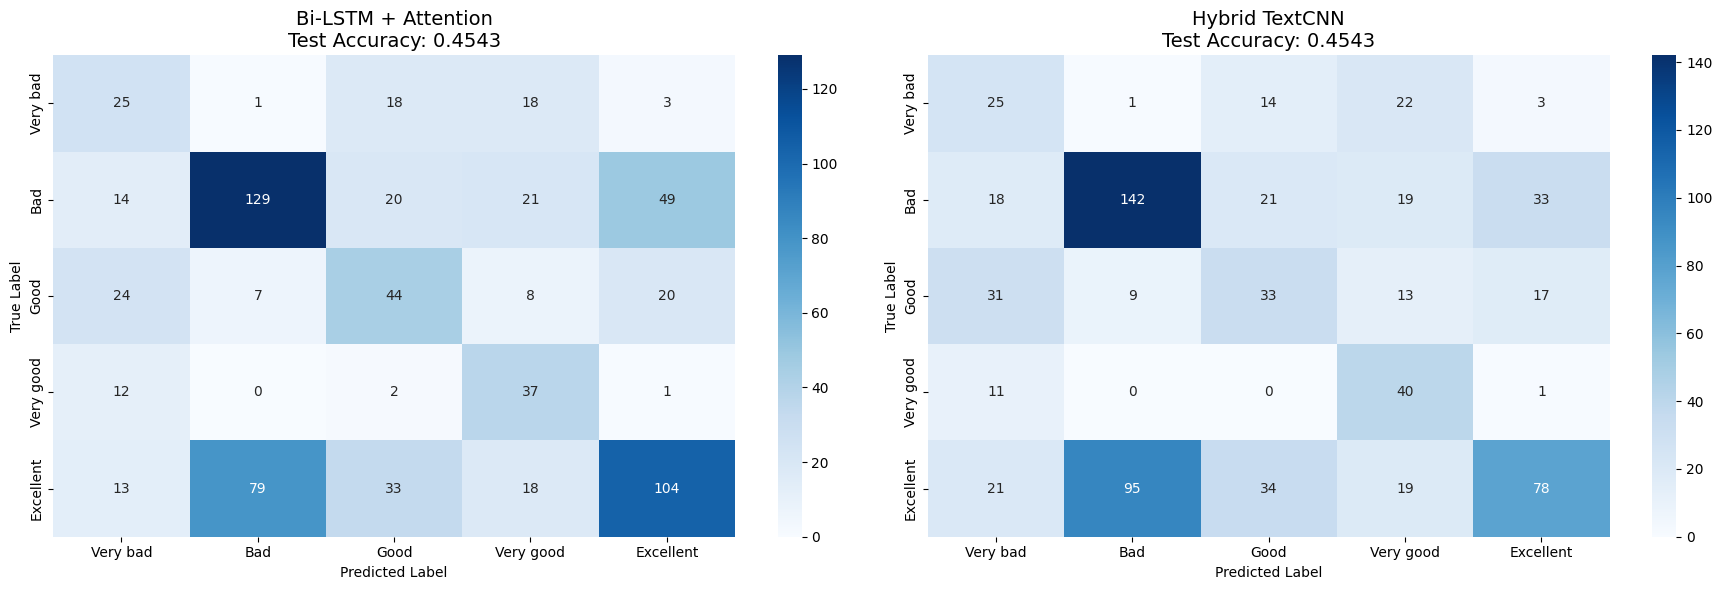


All hybrid models trained, evaluated, and visualized successfully!
Best models saved as:
   → best_Bi-LSTM___Attention.keras
   → best_Hybrid_TextCNN.keras


In [ ]:
MAX_LEN = 128
max_length = MAX_LEN
X_text_train = train_tokens          # padded token IDs
X_aux_train  = train_aux             # VADER + BERT score
X_text_val   = val_tokens
X_aux_val    = val_aux
X_text_test  = test_tokens
X_aux_test   = test_aux

# One-hot encode labels
y_train_onehot = enc.transform(y_train.reshape(-1, 1))
y_val_onehot   = enc.transform(y_val.reshape(-1, 1))
y_test_onehot  = enc.transform(test_y.reshape(-1, 1))   # test_y = your test labels

MODELS = {
    "Bi-LSTM + Attention": create_hybrid_bilstm_attention(
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=300,
        hidden_dim=128,
        aux_dim=2,
        output_dim=5,
        dropout=0.5,
        embedding_matrix=pretrained_weights
    ),
    "Hybrid TextCNN": create_hybrid_textcnn(
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=300,
        n_filters=128,
        filter_sizes=[3, 4, 5],
        aux_dim=2,
        output_dim=5,
        dropout=0.5,
        embedding_matrix=pretrained_weights
    )
}

results = {}
print("="*70)
print("STARTING HYBRID MODELS TRAINING (Bi-LSTM + TextCNN)")
print("="*70)

# Training Loop
for name, model in MODELS.items():
    print(f"\n{'='*25} Training: {name} {'='*25}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Callbacks
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        f'best_{name.replace(" ", "_")}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    )

    # Train
    history = model.fit(
        [X_text_train, X_aux_train], y_train_onehot,
        validation_data=([X_text_val, X_aux_val], y_val_onehot),
        epochs=30,
        batch_size=64,
        callbacks=[checkpoint, early_stop],
        verbose=1
    )

    # Load best model
    best_model_path = f'best_{name.replace(" ", "_")}.keras'
    model = tf.keras.models.load_model(
        best_model_path,
        custom_objects={'AttentionLayer': AttentionLayer}  # Only needed for Bi-LSTM
    )

    # Test Evaluation
    print(f"\n--- {name} - Final Test Results ---")
    test_pred_proba = model.predict([X_text_test, X_aux_test], verbose=0)
    test_preds = np.argmax(test_pred_proba, axis=1)
    test_true = np.argmax(y_test_onehot, axis=1)

    acc = accuracy_score(test_true, test_preds)
    print(f"Test Accuracy: {acc:.4f}\n")
    print(classification_report(test_true, test_preds,
                                target_names=['Very bad', 'Bad', 'Good', 'Very good', 'Excellent']))

    # Store confusion matrix
    results[name] = confusion_matrix(test_true, test_preds)

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes = axes.flatten()

label_names = ['Very bad', 'Bad', 'Good', 'Very good', 'Excellent']

for ax, (name, cm) in zip(axes, results.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'{name}\nTest Accuracy: {accuracy_score(np.argmax(y_test_onehot,axis=1), np.argmax(model.predict([X_text_test, X_aux_test], verbose=0),axis=1)):.4f}', fontsize=14)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\nAll hybrid models trained, evaluated, and visualized successfully!")
print("Best models saved as:")
print("   → best_Bi-LSTM___Attention.keras")
print("   → best_Hybrid_TextCNN.keras")

## MLP

In [ ]:
# One-hot encode labels
enc = OneHotEncoder(sparse_output=False)
y_train_onehot = enc.fit_transform(y_train.reshape(-1, 1))
y_val_onehot   = enc.transform(y_val.reshape(-1, 1))

# Model hyperparameters
IMG_SIZE   = 302          # 300 (FastText) + 1 (VADER) + 1 (BERT score)
LR         = 0.001
MODEL_NAME = 'review_sentiment_mlp'

# MLP model using Sequential API
model = Sequential([
    # First hidden layer
    Dense(512, activation='relu', input_shape=(IMG_SIZE,)),
    Dropout(0.5),                     # Regularization

    # Second hidden layer
    Dense(512, activation='relu'),
    Dropout(0.5),

    # Third hidden layer
    Dense(256, activation='relu'),
    Dropout(0.5),

    # Fourth hidden layer (no dropout, as in original design)
    Dense(128, activation='relu'),

    # Output layer: 5 classes with softmax activation
    Dense(5, activation='softmax')
], name=MODEL_NAME

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='categorical_crossentropy',   # Multi-class classification
    metrics=['accuracy']
)

# model summary
model.summary()

# Set up TensorBoard for training monitoring
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=f'./logs/{MODEL_NAME}',
    histogram_freq=1,
    write_graph=True,
    write_images=False
)

# Train model
print("Starting training...")
history = model.fit(
    X_train, y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=20,
    batch_size=32,
    callbacks=[tensorboard_callback],
    verbose=1
)

# Save the trained model
model.save('model_mlp.keras')
print("MLP model training completed and saved as 'model_mlp.keras'")

# Optional: Save encoder for inference
import joblib
joblib.dump(enc, 'label_encoder.joblib')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "review_sentiment_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 512)            │       155,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 582,661 (2.22 MB)

 Trainable params: 582,661 (2.22 MB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4265 - loss: 1.2951 - val_accuracy: 0.4900 - val_loss: 1.1814
Epoch 2/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4923 - loss: 1.1704 - val_accuracy: 0.4929 - val_loss: 1.1427
Epoch 3/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5144 - loss: 1.1493 - val_accuracy: 0.4943 - val_loss: 1.1266
Epoch 4/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5147 - loss: 1.1465 - val_accuracy: 0.4914 - val_loss: 1.1674
Epoch 5/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5249 - loss: 1.1137 - val_accuracy: 0.4800 - val_loss: 1.1662
Epoch 6/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5217 - loss: 1.1082 - val_accuracy: 0.4900 - val_loss: 1.1494
Epoch 7/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5365 - loss: 1.0986 - val_accuracy: 0.5129 - val_loss: 1.1095
Epoch 8/20
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5395 - loss: 1.0

['label_encoder.joblib']

## LSTM

In [ ]:
# Reshape data
X_train_lstm = X_train.reshape(-1, 302, 1)   # Shape: (samples, 302, 1)
X_val_lstm   = X_val.reshape(-1, 302, 1)

MODEL_NAME = 'review_sentiment_lstm'

# LSTM model using Sequential API
model_lstm = Sequential([
    Input(shape=(302, 1), name='sequence_input'),

    # First LSTM layer
    LSTM(128, return_sequences=True, name='lstm_1'),
    Dropout(0.5, name='dropout_1'),

    # Second LSTM layer — returns only final hidden state
    LSTM(128, return_sequences=False, name='lstm_2'),
    Dropout(0.5, name='dropout_2'),

    # Fully connected hidden layer
    Dense(128, activation='relu', name='dense_hidden'),
    Dropout(0.5, name='dropout_3'),

    # Output layer: 5 sentiment classes
    Dense(5, activation='softmax', name='predictions')
], name=MODEL_NAME)

model_lstm.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Optional: display architecture
model_lstm.summary()

# TensorBoard callback for training visualization
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=f'./logs/{MODEL_NAME}',
    histogram_freq=1,
    write_graph=True
)

# Train the model
print("Starting LSTM training...")
history_lstm = model_lstm.fit(
    X_train_lstm, y_train_onehot,
    validation_data=(X_val_lstm, y_val_onehot),
    epochs=30,
    batch_size=64,                    # Larger batch = faster + more stable gradients
    callbacks=[tensorboard_callback],
    verbose=1
)

# Save the trained model
model_lstm.save('model_lstm.keras')
print("LSTM model training completed and saved as 'model_lstm.keras'")

Model: "review_sentiment_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 302, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 302, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,301 (841.02 KB)

 Trainable params: 215,301 (841.02 KB)

 Non-trainable params: 0 (0.00 B)

Starting LSTM training...
Epoch 1/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.3332 - loss: 1.5064 - val_accuracy: 0.4186 - val_loss: 1.2792
Epoch 2/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.4268 - loss: 1.2611 - val_accuracy: 0.4271 - val_loss: 1.2153
Epoch 3/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4615 - loss: 1.2223 - val_accuracy: 0.4843 - val_loss: 1.1963
Epoch 4/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4799 - loss: 1.2084 - val_accuracy: 0.4914 - val_loss: 1.2249
Epoch 5/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.4989 - loss: 1.1984 - val_accuracy: 0.4914 - val_loss: 1.2049
Epoch 6/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4826 - loss: 1.1985 - val_accuracy: 0.4929 - val_loss: 1.2161
Epoch 7/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.4993 - loss: 1.1814 - val_accuracy: 0.4929 - val_loss: 1.2155
Epoch 8/30
155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4969

## TextCNN - 2

In [ ]:
IMG_SIZE   = 302                    # Feature vector length (FastText 300 + VADER + BERT score)
MODEL_NAME = 'review_sentiment_textcnn'

# Reshape to treat 302 features as a 1D "sequence" → enables 1D convolutions
X_train_cnn = X_train.reshape(-1, IMG_SIZE, 1)   # Shape: (samples, 302, 1)
X_val_cnn   = X_val.reshape(-1, IMG_SIZE, 1)

# Functional API – required for parallel branches
inputs = Input(shape=(IMG_SIZE, 1), name='feature_sequence_input')

# Parallel convolution branches with different kernel sizes (like n-gram detectors)
branch3 = Conv1D(filters=128, kernel_size=3, activation='relu', name='conv_k3')(inputs)
branch3 = GlobalMaxPooling1D(name='pool_k3')(branch3)

branch4 = Conv1D(filters=128, kernel_size=4, activation='relu', name='conv_k4')(inputs)
branch4 = GlobalMaxPooling1D(name='pool_k4')(branch4)

branch5 = Conv1D(filters=128, kernel_size=5, activation='relu', name='conv_k5')(inputs)
branch5 = GlobalMaxPooling1D(name='pool_k5')(branch5)

# Merge all branch outputs → concatenated feature map
merged = concatenate([branch3, branch4, branch5], name='merge_branches')  # Shape: (batch, 384)

# Fully connected classifier head
x = Dense(512, activation='relu', name='fc_512')(merged)
x = Dropout(0.5, name='dropout_1')(x)

x = Dense(256, activation='relu', name='fc_256')(x)
x = Dropout(0.5, name='dropout_2')(x)

# Output layer: 5 sentiment classes
outputs = Dense(5, activation='softmax', name='predictions')(x)

model_textcnn = Model(inputs=inputs, outputs=outputs, name=MODEL_NAME)

model_textcnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model_textcnn.summary()

# TensorBoard callback for monitoring
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=f'./logs/{MODEL_NAME}',
    histogram_freq=1,
    write_graph=True,
    profile_batch=0
)

print("Starting TextCNN training...")
history_textcnn = model_textcnn.fit(
    X_train_cnn, y_train_onehot,
    validation_data=(X_val_cnn, y_val_onehot),
    epochs=30,
    batch_size=32,
    callbacks=[tensorboard_callback],
    verbose=1
)

# Save the trained model
model_textcnn.save('model_textcnn.keras')
print("Advanced TextCNN model training completed and saved as 'model_textcnn.keras'")

Model: "review_sentiment_textcnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ feature_sequence_i… │ (None, 302, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k3 (Conv1D)    │ (None, 300, 128)  │        512 │ feature_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k4 (Conv1D)    │ (None, 299, 128)  │        640 │ feature_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_k5 (Conv1D)    │ (None, 298, 128)  │        768 │ feature_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k3             │ (None, 128)       │          0 │ conv_k3[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k4             │ (None, 128)       │          0 │ conv_k4[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_k5             │ (None, 128)       │          0 │ conv_k5[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_branches      │ (None, 384)       │          0 │ pool_k3[0][0],    │
│ (Concatenate)       │                   │            │ pool_k4[0][0],    │
│                     │                   │            │ pool_k5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_512 (Dense)      │ (None, 512)       │    197,120 │ merge_branches[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ fc_512[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_256 (Dense)      │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ fc_256[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predictions (Dense) │ (None, 5)         │      1,285 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 331,653 (1.27 MB)

 Trainable params: 331,653 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Starting TextCNN training...
Epoch 1/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.4125 - loss: 1.3198 - val_accuracy: 0.4929 - val_loss: 1.2884
Epoch 2/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4984 - loss: 1.1862 - val_accuracy: 0.4957 - val_loss: 1.2143
Epoch 3/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5141 - loss: 1.1703 - val_accuracy: 0.4914 - val_loss: 1.2221
Epoch 4/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5222 - loss: 1.1707 - val_accuracy: 0.4929 - val_loss: 1.3046
Epoch 5/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5074 - loss: 1.1732 - val_accuracy: 0.4929 - val_loss: 1.1804
Epoch 6/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5142 - loss: 1.1677 - val_accuracy: 0.4943 - val_loss: 1.1416
Epoch 7/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5165 - loss: 1.1804 - val_accuracy: 0.4957 - val_loss: 1.2972
Epoch 8/30
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5196 - 

Starting evaluation for 3 models...

Evaluating MLP...
MLP Test Accuracy: 0.4729

--- MLP Classification Report ---
              precision    recall  f1-score   support

           0     0.2796    0.4000    0.3291        65
           1     0.6020    0.5193    0.5576       233
           2     0.3197    0.3786    0.3467       103
           3     0.4062    0.7500    0.5270        52
           4     0.5638    0.4291    0.4874       247

    accuracy                         0.4729       700
   macro avg     0.4343    0.4954    0.4496       700
weighted avg     0.5025    0.4729    0.4783       700

Evaluating LSTM...
LSTM Test Accuracy: 0.4800

--- LSTM Classification Report ---
              precision    recall  f1-score   support

           0     0.2653    0.4000    0.3190        65
           1     0.6009    0.5494    0.5740       233
           2     0.3619    0.3689    0.3654       103
           3     0.3696    0.6538    0.4722        52
           4     0.5729    0.4453    0.501

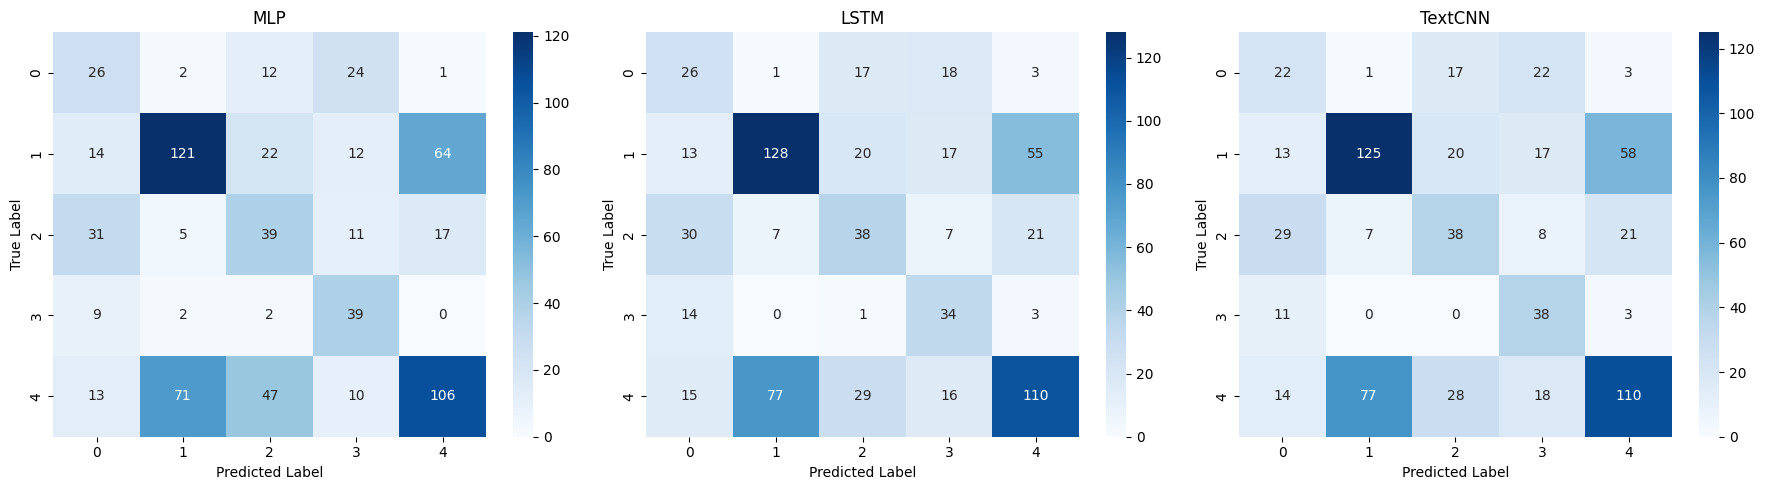

In [ ]:
def evaluate_keras_models(X_test, y_test):
    results_cm = {} # To store confusion matrices

    keras_models = {
        "MLP": ("model_mlp.keras", lambda x: x),                              # Flat input
        "LSTM": ("model_lstm.keras", lambda x: x.reshape(-1, 302, 1)),         # Reshape to 3D
        "TextCNN": ("model_textcnn.keras", lambda x: x.reshape(-1, 302, 1)),    # Reshape to 3D
    }

    print(f"Starting evaluation for {len(keras_models)} models...\n")

    for name, (path, preproc_func) in keras_models.items():
        print(f"{'='*30}\nEvaluating {name}...\n{'='*30}")

        try:
            # 1. Load model
            model = tf.keras.models.load_model(path)

            # 2. Prepare data
            X_input = preproc_func(X_test)

            # 3. Predict
            probs = model.predict(X_input, verbose=0)
            preds = np.argmax(probs, axis=1)

            # 4. Metrics
            acc = accuracy_score(y_test, preds)
            print(f"{name} Test Accuracy: {acc:.4f}")
            print(f"\n--- {name} Classification Report ---")
            print(classification_report(y_test, preds, digits=4))

            # Store for plotting
            results_cm[name] = confusion_matrix(y_test, preds)

        except Exception as e:
            print(f"Failed to evaluate {name}. Error: {e}")

    # Visualization
    print(f"\n{'='*30}\nGenerating Visualizations...\n{'='*30}")

    num_models = len(results_cm)
    if num_models > 0:
        fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))

        if num_models == 1: axes = [axes]

        for i, (name, cm) in enumerate(results_cm.items()):
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
            axes[i].set_title(name)
            axes[i].set_ylabel('True Label')
            axes[i].set_xlabel('Predicted Label')

        plt.tight_layout()
        plt.show()

# Run

# 1. Prepare y_test (integers)
# If y_test is One-Hot (e.g. [[0, 1, 0, 0, 0], ...]), convert back to integers [1, ...]
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_integers = np.argmax(y_test, axis=1)
else:
    y_test_integers = y_test

# 2. Run Evaluation
evaluate_keras_models(X_test, y_test_integers)

In [ ]:
print(f"X_test shape: {X_test.shape}")


submission_template = test.copy()

keras_models_to_process = {
    "MLP": ("model_mlp.keras", lambda x: x),                            # Flat input
    "LSTM": ("model_lstm.keras", lambda x: x.reshape(-1, 302, 1)),       # 3D input
    "TextCNN": ("model_textcnn.keras", lambda x: x.reshape(-1, 302, 1))  # 3D input
}

# PREDICTION LOOP
for name, (model_path, input_transform) in keras_models_to_process.items():
    print(f"\n{'='*30}\nProcessing {name}...\n{'='*30}")

    if not os.path.exists(model_path):
        print(f"Skipping {name}: {model_path} not found.")
        continue

    try:
        model = tf.keras.models.load_model(model_path)
        print(f"Loaded {model_path}")

        X_input = input_transform(X_test)

        probs = model.predict(X_input, verbose=0)

        pred_indices = np.argmax(probs, axis=1)

        # Convert indices (0-4) back to original labels (e.g., 1-5 or 'Negative' etc.)
        if 'enc' in locals():
            final_preds = enc.categories_[0][pred_indices]
        else:
            print("Warning: 'enc' not found. Saving raw indices (0-4).")
            final_preds = pred_indices

        # Save CSV
        submission = submission_template.copy()

        if 'text' in submission.columns:
            submission.drop(columns=['text'], inplace=True)
        if 'label' in submission.columns: # Remove dummy labels if present
            submission.drop(columns=['label'], inplace=True)

        submission['review'] = final_preds

        csv_filename = f"{name}_predictions.csv"
        submission.to_csv(csv_filename, index=False)
        print(f"-> Saved predictions to {csv_filename}")
        # Download the predictions CSV
        files.download(csv_filename)

        # Download the model file itself (Keras models don't need pickling)
        files.download(model_path)

    except Exception as e:
        print(f"Error processing {name}: {e}")

X_test shape: (700, 302)

Processing MLP...
Loaded model_mlp.keras
Error processing MLP: Length of values (700) does not match length of index (3000)

Processing LSTM...
Loaded model_lstm.keras
Error processing LSTM: Length of values (700) does not match length of index (3000)

Processing TextCNN...
Loaded model_textcnn.keras
Error processing TextCNN: Length of values (700) does not match length of index (3000)


## **CSVs**

In [ ]:
while True:
  pass

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from google.colab import files
import os

def generate_submissions(X_test, original_template_df, backup_df=None):

    print(f"Input X_test shape: {X_test.shape}")

    submission_template = original_template_df.copy()

    if len(submission_template) != len(X_test):
        print(f"⚠️ Mismatch Detected! Template has {len(submission_template)} rows, but X_test has {len(X_test)}.")

        if backup_df is not None and len(backup_df) == len(X_test):
            print("✅ Switching submission template to 'backup_df' (matches X_test size).")
            submission_template = backup_df.copy()
        else:
            print("⚠️ Warning: Could not find a matching dataframe variable.")
            print("Creating a generic dataframe for predictions only.")
            submission_template = pd.DataFrame(index=range(len(X_test))
            if backup_df is not None and 'id' in backup_df.columns:
                 submission_template['id'] = backup_df['id'].values[:len(X_test)]

    keras_models_to_process = {
        "MLP": ("model_mlp.keras", lambda x: x),                            # Flat input
        "LSTM": ("model_lstm.keras", lambda x: x.reshape(-1, 302, 1)),       # 3D input
        "TextCNN": ("model_textcnn.keras", lambda x: x.reshape(-1, 302, 1))  # 3D input
    }

    for name, (model_path, input_transform) in keras_models_to_process.items():
        print(f"\n{'='*30}\nProcessing {name}...\n{'='*30}")

        if not os.path.exists(model_path):
            print(f"Skipping {name}: {model_path} not found.")
            continue

        try:
            model = tf.keras.models.load_model(model_path)
            print(f"Loaded {model_path}")

            X_input = input_transform(X_test)

            # Predict
            probs = model.predict(X_input, verbose=0)
            pred_indices = np.argmax(probs, axis=1)

            if 'enc' in globals():
                final_preds = enc.categories_[0][pred_indices]
            else:
                print("Warning: 'enc' not found in global scope. Saving raw indices.")
                final_preds = pred_indices

            # Save CSV
            # Reset the dataframe for this iteration
            submission = submission_template.copy()

            cols_to_drop = ['text', 'label', 'review', 'clean_text', 'vader_compound', 'bert_score']
            for col in cols_to_drop:
                if col in submission.columns:
                    submission.drop(columns=[col], inplace=True)

            # Assign predictions
            submission['review'] = final_preds

            csv_filename = f"{name}_predictions.csv"
            submission.to_csv(csv_filename, index=False)
            print(f"-> Saved predictions to {csv_filename}")

            # Download
            files.download(csv_filename)

        except Exception as e:
            print(f"❌ Error processing {name}: {e}")


X_test, y_test = preprocess_test_data(test, ft_model, sentiment_pipeline, sid, tknzr, stop_words, label_mapping)

generate_submissions(X_test, test, backup_df=backup_dataframe)

## **Test Script**

In [ ]:
# @title 🚀 Run Predictions


import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import nltk
import fasttext
import fasttext.util
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline
nltk.download('vader_lexicon', quiet=True)

# --- 🛠️ LABEL MAPPING 🛠️ ---
LABEL_MAPPING = {
    0: "Bad",
    1: "Excellent",
    2: "Good",
    3: "Very bad",
    4: "Very good"
}

@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        super().build(input_shape)
    def call(self, lstm_output):
        score = tf.tanh(lstm_output)
        score = tf.matmul(score, self.W)
        weights = tf.nn.softmax(score, axis=1)
        context = weights * lstm_output
        context = tf.reduce_sum(context, axis=1)
        return context
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])
    def get_config(self):
        return super().get_config()

# Initialize Feature Tools
vader_analyzer = SentimentIntensityAnalyzer()
print("Loading BERT pipeline...")
bert_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", top_k=None)
FASTTEXT_PATH = '/content/drive/MyDrive/fasttext-wiki-news-subwords-300.model'

if 'ft_model' not in globals():
    if os.path.exists(FASTTEXT_PATH):
        print(f"Loading FastText from {FASTTEXT_PATH}...")
        try:
            ft_model = fasttext.load_model(FASTTEXT_PATH)
        except:
            print("Official load failed, trying Gensim...")
            from gensim.models import KeyedVectors
            ft_model = KeyedVectors.load(FASTTEXT_PATH)
    else:
        print(f"⚠️ FastText not found at {FASTTEXT_PATH}. Using placeholders.")
        ft_model = None

# Helper Functions
def get_bert_score(text):
    try:
        preds = bert_pipeline(text[:512])
        for p in preds[0]:
            if p['label'] == 'POSITIVE': return p['score']
        return 0.5
    except: return 0.5

def get_vector_safe(model, word):
    if hasattr(model, 'get_word_vector'): return model.get_word_vector(word)
    try: return model[word]
    except: return np.zeros(300)

def get_embedding_vector(text):
    text = str(text)
    if ft_model:
        words = text.split()
        word_vecs = [get_vector_safe(ft_model, w) for w in words]
        text_emb = np.mean(word_vecs, axis=0) if len(word_vecs) > 0 else np.zeros(300)
    else:
        text_emb = np.zeros(300)
    vader = vader_analyzer.polarity_scores(text)['compound']
    bert = get_bert_score(text)
    return np.concatenate([text_emb, [vader], [bert]])

# ==========================================
# 2. MAIN PREDICTION PIPELINE
# ==========================================
def run_prediction_pipeline(file_path):
    # --- A. Validation ---
    if not os.path.exists(file_path):
        print(f"❌ Error: File not found at '{file_path}'")
        return

    encoder_path = 'label_encoder.joblib'
    if not os.path.exists(encoder_path):
        print(f"❌ Error: '{encoder_path}' missing. Cannot decode labels.")
        return

    # --- B. Load Data ---
    print(f"\n📄 Processing: {file_path}")
    df = pd.read_csv(file_path)

    possible_text = [c for c in df.columns if c.lower() in ['text', 'review', 'reviews', 'content', 'body']]
    text_col = possible_text[0] if possible_text else df.select_dtypes(include=['object']).apply(lambda x: x.str.len().mean()).idxmax()
    print(f"✅ Text column: '{text_col}'")
    id_col = 'id' if 'id' in df.columns else None
    if not id_col:
        df['id'] = range(1, len(df) + 1)
        id_col = 'id'
    print("🧠 Extracting features...")
    try:
        X_raw = np.stack(df[text_col].apply(get_embedding_vector).values)
    except Exception as e:
        print(f"❌ Feature generation failed: {e}")
        return

    # Scaling
    scaler_path = 'scaler.joblib'
    if os.path.exists(scaler_path):
        print("⚖️ Applying Scaler...")
        scaler = joblib.load(scaler_path)
        try: X_raw = scaler.transform(X_raw)
        except: print("⚠️ Scaler mismatch. Skipping.")

    # --- D. Model Loop ---
    enc = joblib.load(encoder_path)

    target_models = ['model_mlp.keras', 'model_lstm.keras', 'model_textcnn.keras']
    found_models = [f for f in os.listdir('.') if f in target_models]

    if not found_models:
        print("❌ No target models found.")
        return

    # Output Folder
    output_folder = "model_predictions"
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    print(f"\n📂 Created folder: '{output_folder}'")

    print(f"🚀 Running predictions on {len(found_models)} models...")

    for m_file in found_models:
        try:
            # 1. Load
            model = load_model(m_file, custom_objects={'AttentionLayer': AttentionLayer})
            input_shape = model.inputs[0].shape
            if input_shape[1] != 302:
                print(f"⚠️ Skipping {m_file}: Incompatible input shape {input_shape}")
                continue

            if len(input_shape) == 3: # LSTM/CNN
                 X_in = X_raw.reshape(X_raw.shape[0], 302, 1)
            else: # MLP
                 X_in = X_raw

            # Predict
            print(f"   Running {m_file}...", end=" ")
            probs = model.predict(X_in, verbose=0)
            decoded_preds = enc.inverse_transform(probs).flatten()
            final_preds_series = pd.Series(decoded_preds)
            if pd.api.types.is_numeric_dtype(final_preds_series):
                final_preds_series = final_preds_series.map(LABEL_MAPPING).fillna(final_preds_series)
            output_df = pd.DataFrame({
                'id': df[id_col],
                'review': final_preds_series
            })

            # Save
            save_name = f"prediction_{m_file.replace('.keras', '')}.csv"
            save_path = os.path.join(output_folder, save_name)
            output_df.to_csv(save_path, index=False)
            print(f"✅ Saved: {save_name}")

        except Exception as e:
            print(f"\n❌ {m_file} Failed: {e}")

    print(f"\n🎉 Done! Check the '{output_folder}' folder.")

# ==========================================
# (Don't forget to use the new test path)
# ==========================================
target_file_path = "/content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv"

# # @param {type:"string"}

if __name__ == "__main__":
    run_prediction_pipeline(target_file_path)

Loading BERT pipeline...

📄 Processing: /content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv
✅ Text column: 'text'
🧠 Extracting features...

📂 Created folder: 'model_predictions'
🚀 Running predictions on 3 models...
   Running model_mlp.keras... ✅ Saved: prediction_model_mlp.csv
   Running model_lstm.keras... ✅ Saved: prediction_model_lstm.csv
   Running model_textcnn.keras... ✅ Saved: prediction_model_textcnn.csv

🎉 Done! Check the 'model_predictions' folder.


In [ ]:
!pip install tensorflow pandas numpy scikit-learn nltk transformers fasttext

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4498212 sha256=fae9a0fd22d9115f7e5de5bd2261e5317d7b777aceb9715b173698742e7b83fe
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [ ]:
# @title 🚀 Run Predictions (LSTM & TextCNN Only)

import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import nltk
import fasttext
import fasttext.util
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import pipeline

# ==========================================
# 1. CONFIGURATION & MAPPING
# ==========================================
nltk.download('vader_lexicon', quiet=True)

# 🛠️ YOUR CUSTOM MAPPING 🛠️
LABEL_MAPPING = {
    0: "Bad",
    1: "Excellent",
    2: "Good",
    3: "Very bad",
    4: "Very good"
}

# Define Custom Layer (Needed to load the file)
@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), initializer='glorot_uniform', trainable=True)
        super().build(input_shape)
    def call(self, lstm_output):
        score = tf.tanh(lstm_output)
        score = tf.matmul(score, self.W)
        weights = tf.nn.softmax(score, axis=1)
        context = weights * lstm_output
        context = tf.reduce_sum(context, axis=1)
        return context
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])
    def get_config(self):
        return super().get_config()

# Initialize Tools
vader_analyzer = SentimentIntensityAnalyzer()
print("Loading BERT pipeline...")
bert_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", top_k=None)
FASTTEXT_PATH = '/content/drive/MyDrive/fasttext-wiki-news-subwords-300.model'

if 'ft_model' not in globals():
    if os.path.exists(FASTTEXT_PATH):
        print(f"Loading FastText from {FASTTEXT_PATH}...")
        try:
            ft_model = fasttext.load_model(FASTTEXT_PATH)
        except:
            print("Official load failed, trying Gensim...")
            from gensim.models import KeyedVectors
            ft_model = KeyedVectors.load(FASTTEXT_PATH)
    else:
        print(f"⚠️ FastText not found at {FASTTEXT_PATH}. Using placeholders.")
        ft_model = None

# Helper Functions
def get_bert_score(text):
    try:
        preds = bert_pipeline(text[:512])
        for p in preds[0]:
            if p['label'] == 'POSITIVE': return p['score']
        return 0.5
    except: return 0.5

def get_vector_safe(model, word):
    if hasattr(model, 'get_word_vector'): return model.get_word_vector(word)
    try: return model[word]
    except: return np.zeros(300)

def get_embedding_vector(text):
    text = str(text)
    if ft_model:
        words = text.split()
        word_vecs = [get_vector_safe(ft_model, w) for w in words]
        text_emb = np.mean(word_vecs, axis=0) if len(word_vecs) > 0 else np.zeros(300)
    else:
        text_emb = np.zeros(300)
    vader = vader_analyzer.polarity_scores(text)['compound']
    bert = get_bert_score(text)
    return np.concatenate([text_emb, [vader], [bert]])

# ==========================================
# 2. MAIN PIPELINE
# ==========================================
def run_prediction_pipeline(file_path):
    if not os.path.exists(file_path):
        print(f"❌ Error: File not found at '{file_path}'")
        return

    # --- Load Data ---
    print(f"\n📄 Processing: {file_path}")
    df = pd.read_csv(file_path)

    # Text Column
    possible_text = [c for c in df.columns if c.lower() in ['text', 'review', 'reviews', 'content', 'body']]
    text_col = possible_text[0] if possible_text else df.select_dtypes(include=['object']).apply(lambda x: x.str.len().mean()).idxmax()
    print(f"✅ Text column: '{text_col}'")

    # ID Column
    id_col = 'id' if 'id' in df.columns else None
    if not id_col:
        df['id'] = range(1, len(df) + 1)
        id_col = 'id'

    # --- Feature Extraction ---
    print("🧠 Extracting features...")
    try:
        X_raw = np.stack(df[text_col].apply(get_embedding_vector).values)
    except Exception as e:
        print(f"❌ Feature generation failed: {e}")
        return

    # Scaling
    scaler_path = 'scaler.joblib'
    if os.path.exists(scaler_path):
        print("⚖️ Applying Scaler...")
        scaler = joblib.load(scaler_path)
        try: X_raw = scaler.transform(X_raw)
        except: print("⚠️ Scaler mismatch. Skipping.")

    # --- Model Loop ---
    # Only target LSTM and TextCNN
    target_models = ['model_lstm.keras', 'model_textcnn.keras']
    found_models = [f for f in os.listdir('.') if f in target_models]

    if not found_models:
        print(f"❌ No target models found. Looked for: {target_models}")
        return

    # Create Output Folder
    output_folder = "model_predictions"
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)
    os.makedirs(output_folder)
    print(f"\n📂 Created folder: '{output_folder}'")

    print(f"🚀 Running predictions on {len(found_models)} models...")

    for m_file in found_models:
        try:
            # 1. Load Model
            model = load_model(m_file, custom_objects={'AttentionLayer': AttentionLayer})

            # 2. Reshape Input (Both LSTM and TextCNN need 3D input)
            # Original Shape: (Batch, 302) -> New Shape: (Batch, 302, 1)
            X_in = X_raw.reshape(X_raw.shape[0], 302, 1)

            # 3. Predict
            print(f"   Running {m_file}...", end=" ")
            probs = model.predict(X_in, verbose=0)

            # 4. Get Predicted Class Index (0-4)
            pred_indices = np.argmax(probs, axis=1)

            # 5. Map to Text Labels using YOUR Mapping
            preds_text = [LABEL_MAPPING.get(idx, "Unknown") for idx in pred_indices]

            # 6. Save CSV
            output_df = pd.DataFrame({
                'id': df[id_col],
                'review': preds_text
            })

            save_name = f"prediction_{m_file.replace('.keras', '')}.csv"
            save_path = os.path.join(output_folder, save_name)
            output_df.to_csv(save_path, index=False)
            print(f"✅ Saved: {save_name}")

        except Exception as e:
            print(f"\n❌ {m_file} Failed: {e}")

    print(f"\n🎉 Done! Check the '{output_folder}' folder.")

# ==========================================
# 3. USER INPUT
# ==========================================
target_file_path = "/content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv" # @param {type:"string"}

if __name__ == "__main__":
    run_prediction_pipeline(target_file_path)

Loading BERT pipeline...

📄 Processing: /content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv
✅ Text column: 'text'
🧠 Extracting features...

📂 Created folder: 'model_predictions'
🚀 Running predictions on 2 models...
   Running model_lstm.keras... ✅ Saved: prediction_model_lstm.csv
   Running model_textcnn.keras... ✅ Saved: prediction_model_textcnn.csv

🎉 Done! Check the 'model_predictions' folder.


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Layer

@tf.keras.utils.register_keras_serializable()
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            shape=(input_shape[-1], 1),
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, lstm_output):
        score = tf.matmul(tf.tanh(lstm_output), self.W)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * lstm_output, axis=1)
        return context

LABEL_MAPPING = {
    0: "Bad",
    1: "Excellent",
    2: "Good",
    3: "Very bad",
    4: "Very good"
}


def run_full_pipeline(file_path):

    print(f"\n📄 Processing: {file_path}")
    df = pd.read_csv(file_path)
    if 'id' not in df.columns:
        print("⚠️ 'id' column missing. Creating sequential IDs.")
        df['id'] = range(1, len(df) + 1)

    output_dir = "model_outputs"
    os.makedirs(output_dir, exist_ok=True)


    print("\n🧠 Running vector preprocessing (FastText + VADER + BERT)...")
    X_vector, _ = preprocess_test_data(
        df=df,
        ft_model=ft_model,
        sentiment_pipeline=sentiment_pipeline,
        sid=sid,
        tknzr=tknzr,
        stop_words=stop_words,
        label_mapping=None
    )

    print("\n🔤 Running glass-box preprocessing (Tokenizer + Aux features)...")
    scaler = joblib.load("scaler_glassbox.pkl")

    X_tokens, X_aux, _, _ = preprocess_glass_box_data(
        df=df,
        vocab=vocab,
        max_len=max_len,
        sentiment_pipeline=sentiment_pipeline,
        sid=sid,
        scaler=scaler,
        label_mapping=None,
        is_training=False
    )

    model_files = [
        f for f in os.listdir('.')
        if f.endswith('.keras')
        and any(x in f.lower() for x in ['best', 'mlp'])
    ]

    print(f"\n🚀 Running {len(model_files)} models...")

    for m_file in model_files:
        try:
            print(f"▶ Loading {m_file}")
            model = load_model(
                m_file,
                custom_objects={'AttentionLayer': AttentionLayer}
            )

            inputs = model.inputs

            if inputs[0].shape[-1] == 302:
                X_in = X_vector

                if len(inputs[0].shape) == 3:
                    X_in = X_vector.reshape(X_vector.shape[0], 302, 1)

            elif len(inputs) == 2:
              X_in = [X_tokens, X_aux]

            elif inputs[0].shape[1] == max_len:
                X_in = X_tokens

            else:
                print(f"⚠️ Skipping {m_file}: unsupported input structure")
                continue

            probs = model.predict(X_in, verbose=0)
            if probs.shape[1] == 1:
                pred_idx = (probs > 0.5).astype(int).flatten()
            else:
                pred_idx = np.argmax(probs, axis=1)
            preds = pd.Series(pred_idx).map(LABEL_MAPPING).values
            if pd.isna(preds).any():
                print("⚠️ Warning: Some predicted indices were not found in LABEL_MAPPING.")
                preds = pd.Series(preds).fillna("Unknown").values

            out_df = pd.DataFrame({
                'id': df['id'],
                'review': preds
            })

            out_path = os.path.join(
                output_dir,
                m_file.replace('.keras', '.csv')
            )

            out_df.to_csv(out_path, index=False)
            print(f"✅ Saved → {out_path}")

        except Exception as e:
            print(f"❌ {m_file} failed: {e}")

    print("\n🎉 All predictions completed")


# ==========================================
# (Don't forget to use the new test path)
# ==========================================
run_full_pipeline(
    "/content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv"
)


📄 Processing: /content/drive/MyDrive/NeuralNetworksProjectDataset/test.csv

🧠 Running vector preprocessing (FastText + VADER + BERT)...
Generating VADER scores...
Cleaning text (Light Clean for BERT)...
Generating BERT scores (this may take time)...
Cleaning text (Aggressive Clean for FastText)...
Generating FastText embeddings...
Stacking features...
Done! Processed shape: (3000, 302)

🔤 Running glass-box preprocessing (Tokenizer + Aux features)...

🚀 Running 5 models...
▶ Loading model_mlp.keras
✅ Saved → model_outputs/model_mlp.csv
▶ Loading best_TextCNN.keras
✅ Saved → model_outputs/best_TextCNN.csv
▶ Loading best_Bi-LSTM_+_Attention.keras
✅ Saved → model_outputs/best_Bi-LSTM_+_Attention.csv
▶ Loading best_Hybrid_TextCNN.keras
✅ Saved → model_outputs/best_Hybrid_TextCNN.csv
▶ Loading best_Bi-LSTM.keras
✅ Saved → model_outputs/best_Bi-LSTM.csv

🎉 All predictions completed
